# ============================================================
# NOTEBOOK 3 — PREDICTIVE MODELLING & CLINICAL PERFORMANCE
# EVALUATION
# ============================================================

"""
Trustworthy Agentic AI for Healthcare

Stage 3 — Prediction

Objective
---------
This notebook establishes the predictive modelling foundation
for the Trustworthy Agentic AI for Healthcare project.

The notebook evaluates multiple machine-learning approaches
for binary diabetes prediction using the leakage-safe clinical
cohort constructed in Notebook 2.

Key principles
--------------
1. Participant-level train/test separation
2. No target leakage
3. Training-only preprocessing
4. Reproducible model evaluation
5. Clinically relevant performance metrics
6. Calibration and threshold analysis
7. Subgroup performance evaluation
8. Transparent model comparison

No explainability or agentic reasoning is performed here.
Those components are addressed in subsequent stages.

Target
------
diabetes_target

0 = No diabetes
1 = Diabetes
"""

print("=" * 80)
print("NOTEBOOK 3 — PREDICTIVE MODELLING & CLINICAL PERFORMANCE EVALUATION")
print("=" * 80)

print("\nProject:")
print("Trustworthy Agentic AI for Healthcare")

print("\nStage:")
print("3 — Prediction")

print("\nTarget:")
print("diabetes_target")

print("\nNotebook 3 initialised successfully.")

In [1]:
# ============================================================
# CELL 2 — IMPORTS & REPRODUCIBILITY
# ============================================================

import os
import json
import warnings
from sklearn.pipeline import Pipeline
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("=" * 80)
print("IMPORTS & REPRODUCIBILITY")
print("=" * 80)

print("\n✓ NumPy imported")
print("✓ Pandas imported")
print("✓ Scikit-learn imported")
print("✓ Matplotlib imported")
print(f"✓ Random state: {RANDOM_STATE}")

print("\nNotebook 3 environment ready.")

IMPORTS & REPRODUCIBILITY

✓ NumPy imported
✓ Pandas imported
✓ Scikit-learn imported
✓ Matplotlib imported
✓ Random state: 42

Notebook 3 environment ready.


In [2]:
# ============================================================
# CELL 3 — PROJECT DIRECTORIES
# ============================================================

PROJECT_ROOT = Path(
    "/content/trustworthy_agentic_ai_healthcare"
)

DIRS = {
    "root": PROJECT_ROOT,
    "data": PROJECT_ROOT / "data",
    "outputs": PROJECT_ROOT / "outputs",
    "models": PROJECT_ROOT / "models",
    "reports": PROJECT_ROOT / "reports",
    "figures": PROJECT_ROOT / "figures",
    "metadata": PROJECT_ROOT / "metadata",
}

for directory in DIRS.values():
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 80)
print("PROJECT DIRECTORIES")
print("=" * 80)

for name, directory in DIRS.items():
    print(f"{name:12s} -> {directory}")

print("\n✓ Project directories ready.")

PROJECT DIRECTORIES
root         -> /content/trustworthy_agentic_ai_healthcare
data         -> /content/trustworthy_agentic_ai_healthcare/data
outputs      -> /content/trustworthy_agentic_ai_healthcare/outputs
models       -> /content/trustworthy_agentic_ai_healthcare/models
reports      -> /content/trustworthy_agentic_ai_healthcare/reports
figures      -> /content/trustworthy_agentic_ai_healthcare/figures
metadata     -> /content/trustworthy_agentic_ai_healthcare/metadata

✓ Project directories ready.


In [3]:
# ============================================================
# CELL 4 — UPLOAD FINAL MODELLING DATASET
# ============================================================

from google.colab import files

print("=" * 80)
print("UPLOAD FINAL MODELLING DATASET")
print("=" * 80)

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print(" -", filename)

EXPECTED_FILENAME = "diabetes_modeling_dataset_final.csv"

if EXPECTED_FILENAME in uploaded:
    FINAL_MODEL_DATA_PATH = Path(
        f"/content/{EXPECTED_FILENAME}"
    )

    print("\n✓ Correct final modelling dataset detected.")
    print(f"Path: {FINAL_MODEL_DATA_PATH}")

else:
    raise FileNotFoundError(
        f"{EXPECTED_FILENAME} was not uploaded. "
        "Please upload the CSV exported from Notebook 2 Cell 36A."
    )

UPLOAD FINAL MODELLING DATASET


Saving diabetes_modeling_dataset_final.csv to diabetes_modeling_dataset_final.csv

Uploaded files:
 - diabetes_modeling_dataset_final.csv

✓ Correct final modelling dataset detected.
Path: /content/diabetes_modeling_dataset_final.csv


In [4]:
# ============================================================
# CELL 5 — LOAD & VALIDATE FINAL MODELLING DATASET
# ============================================================

print("=" * 80)
print("LOADING FINAL MODELLING DATASET")
print("=" * 80)

df = pd.read_csv(
    FINAL_MODEL_DATA_PATH
)

print("\nDataset loaded successfully.")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\nFirst 5 rows:")
display(df.head())

print("\nTarget distribution:")

print(
    df["diabetes_target"]
    .value_counts()
    .sort_index()
)

print("\nTarget proportions:")

print(
    df["diabetes_target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert "diabetes_target" in df.columns
assert "SEQN" in df.columns

assert "DIQ010" not in df.columns

remaining_diq = [
    col for col in df.columns
    if col.startswith("DIQ")
]

assert len(remaining_diq) == 0

assert df["diabetes_target"].isna().sum() == 0

assert set(
    df["diabetes_target"].unique()
) == {0, 1}

print("\n" + "=" * 80)
print("DATASET VALIDATION")
print("=" * 80)

print("✓ diabetes_target exists")
print("✓ SEQN participant identifier exists")
print("✓ Original DIQ010 is absent")
print("✓ No non-target DIQ variables remain")
print("✓ No missing target values")
print("✓ Target is strictly binary: 0/1")

print("\n✓ Notebook 2 → Notebook 3 handoff validated.")

LOADING FINAL MODELLING DATASET

Dataset loaded successfully.
Rows    : 31,469
Columns : 244

First 5 rows:


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDYRUSZ,DMDEDUC2,DMDMARTZ,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINTPRP,WTMECPRP,SDMVPSU,SDMVSTRA,INDFMPIR,BMDSTATS,BMXWT,BMXHT,BMXBMI,BMDBMIC,BMXLEG,BMXARML,BMXARMC,BMXWAIST,BMXHIP,BPAOARM,BPAOCSZ,BPXOSY1,BPXODI1,BPXOSY2,BPXODI2,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,WTSAFPRP_x,LBXGLU,LBDGLUSI,LBXGH,LBXTC,LBDTCSI,WTSAFPRP_y,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI,LBDLDLM,LBDLDMSI,LBDLDLN,LBDLDNSI,LBDHDD,LBDHDDSI,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,LBDEONO,LBDBANO,LBXRBCSI,LBXHGB,LBXHCT,LBXMCVSI,LBXMC,LBXMCHSI,LBXRDW,LBXPLTSI,LBXMPSI,LBXNRBC,LBXSATSI,LBDSATLC,LBXSAL,LBDSALSI,LBXSAPSI,LBXSASSI,LBXSC3SI,LBXSBU,LBDSBUSI,LBXSCLSI,LBXSCK,LBXSCR,LBDSCRSI,LBXSGB,...,DID350,DBQ700,DBQ197,DBQ223A,DBQ223B,DBQ229,DBQ235A,DBQ235B,DBQ235C,DBQ301,DBQ330,DBQ360,DBQ370,DBD381,DBQ390,DBQ400,DBD411,DBD895,DBD900,DBD905,DBD910,CBQ596,CBQ606,CBQ611,DBQ930,DBQ935,DBQ940,DBQ945,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ151,ALQ170,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD057,SMQ078,SMD641,SMD650,SMD100FL,SMD100MN,SMQ670,SMAQUEX2,HIQ011,HIQ032A,HIQ032B,HIQ032D,HIQ105,HIQ270,HIQ210,HUQ010,HUQ030,HUQ051,HUQ071,HUQ090,RXDUSE,RXDDRUG,RXDDRGID,RXQSEEN,RXDDAYS,RXDRSC1,RXDRSC2,RXDRSC3,RXDRSD1,RXDRSD2,RXDRSD3,RXDCOUNT,diabetes_target
0,109263.0,66.0,2.0,1.0,2.0,5.0,6.0,2.0,1.0,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,7891.762435,8.951816e+03,3.0,156.0,4.66,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.397605e-79,5.397605e-79,5.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,2.0,1.0,1.0,1.000000e+00,2.0,NaN,2.0,b'',b'',NaN,NaN,b'',b'',b'',b'',b'',b'',NaN,0
1,109264.0,66.0,2.0,2.0,13.0,1.0,1.0,2.0,1.0,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,11689.747264,1.227116e+04,1.0,155.0,0.83,1.0,42.2,154.7,17.6,2.0,36.3,33.8,22.7,63.8,85.0,b'R',3.0,109.0,67.0,109.0,68.0,106.0,66.0,94.0,95.0,91.0,27533.174559,97.0,5.38,5.3,166.0,4.29,27533.174559,40.0,0.452,86.0,2.224,82.0,2.121,85.0,2.198,72.0,1.86,4.5,45.6,6.2,46.4,1.4,0.5,2.1,0.3,2.1,0.1,5.397605e-79,4.80,13.7,40.5,84.3,33.7,28.4,13.1,263.0,8.2,0.1,8.0,5.397605e-79,4.3,43.0,172.0,18.0,26.0,9.0,3.21,102.0,48.0,0.57,50.39,2.6,...,NaN,NaN,3.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,5.0,1.0,1.0,1.0,1.0,5.397605e-79,1.000000e+00,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,1.0,2.0,2.0,1.0,5.397605e-79,2.0,1.0,2.0,b'',b'',NaN,NaN,b'',b'',b'',b'',b'',b'',NaN,0
2,109265.0,66.0,2.0,1.0,2.0,3.0,3.0,2.0,1.0,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,16273.825939,1.665876e+04,1.0,157.0,3.06,1.0,12.0,89.3,15.0,2.0,NaN,18.6,14.8,41.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.5,46.4,10.9,39.2,2.9,0.7,4.4,1.0,3.7,0.3,1.000000e-01,4.50,12.6,36.6,81.2,34.4,27.9,13.1,286.0,6.6,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.000000e+00,5.397605e-79,2.000000e


Target distribution:
diabetes_target
0    23004
1     8465
Name: count, dtype: int64

Target proportions:
diabetes_target
0    73.1
1    26.9
Name: proportion, dtype: float64

DATASET VALIDATION
✓ diabetes_target exists
✓ SEQN participant identifier exists
✓ Original DIQ010 is absent
✓ No non-target DIQ variables remain
✓ No missing target values
✓ Target is strictly binary: 0/1

✓ Notebook 2 → Notebook 3 handoff validated.


In [5]:
# ============================================================
# CELL 6 — FEATURE GOVERNANCE AUDIT
# ============================================================

print("=" * 80)
print("FEATURE GOVERNANCE AUDIT")
print("=" * 80)

TARGET_COLUMN = "diabetes_target"
ID_COLUMN = "SEQN"

# Participant identifier
identifier_columns = [
    "SEQN"
]

# NHANES survey design / sampling variables
survey_design_columns = [
    "SDMVPSU",
    "SDMVSTRA",
    "WTINTPRP",
    "WTMECPRP",
    "WTSAFPRP_x",
    "WTSAFPRP_y"
]

# Keep only columns that actually exist
identifier_columns = [
    col for col in identifier_columns
    if col in df.columns
]

survey_design_columns = [
    col for col in survey_design_columns
    if col in df.columns
]

print("\nTarget:")
print(TARGET_COLUMN)

print("\nIdentifier columns:")
for col in identifier_columns:
    print(f" - {col}")

print("\nSurvey design / sampling columns:")
for col in survey_design_columns:
    print(f" - {col}")

print("\nTotal identifier columns:", len(identifier_columns))
print("Total survey design columns:", len(survey_design_columns))

print("\nImportant modelling principle:")
print(
    "Participant identifiers and survey sampling/design variables "
    "will not be treated as ordinary predictive clinical features."
)

FEATURE GOVERNANCE AUDIT

Target:
diabetes_target

Identifier columns:
 - SEQN

Survey design / sampling columns:
 - SDMVPSU
 - SDMVSTRA
 - WTINTPRP
 - WTMECPRP
 - WTSAFPRP_x
 - WTSAFPRP_y

Total identifier columns: 1
Total survey design columns: 6

Important modelling principle:
Participant identifiers and survey sampling/design variables will not be treated as ordinary predictive clinical features.


In [6]:
# ============================================================
# CELL 7 — DEFINE MODELING FEATURES AND TARGET
# ============================================================

print("=" * 80)
print("DEFINE MODELING FEATURES AND TARGET")
print("=" * 80)

# Target
y = df[TARGET_COLUMN].copy()

# Columns that must not enter the predictive feature matrix
excluded_from_features = (
    identifier_columns
    + survey_design_columns
    + [TARGET_COLUMN]
)

# Remove duplicates while preserving order
excluded_from_features = list(
    dict.fromkeys(excluded_from_features)
)

# Feature matrix
X = df.drop(
    columns=excluded_from_features,
    errors="ignore"
).copy()

print("\nOriginal dataset shape:")
print(df.shape)

print("\nFeature matrix shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

print("\nExcluded from predictive features:")
for col in excluded_from_features:
    print(f" - {col}")

print("\nTarget distribution:")
print(
    y.value_counts()
     .sort_index()
)

print("\nTarget proportions (%):")
print(
    y.value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2)
)

print("\n✓ Target separated from predictors.")
print("✓ Identifier excluded.")
print("✓ Survey design variables excluded from ordinary predictors.")

DEFINE MODELING FEATURES AND TARGET

Original dataset shape:
(31469, 244)

Feature matrix shape:
(31469, 236)

Target shape:
(31469,)

Excluded from predictive features:
 - SEQN
 - SDMVPSU
 - SDMVSTRA
 - WTINTPRP
 - WTMECPRP
 - WTSAFPRP_x
 - WTSAFPRP_y
 - diabetes_target

Target distribution:
diabetes_target
0    23004
1     8465
Name: count, dtype: int64

Target proportions (%):
diabetes_target
0    73.1
1    26.9
Name: proportion, dtype: float64

✓ Target separated from predictors.
✓ Identifier excluded.
✓ Survey design variables excluded from ordinary predictors.


In [7]:
# ============================================================
# CELL 8 — FEATURE TYPE AND DATA QUALITY AUDIT
# ============================================================

print("=" * 80)
print("FEATURE TYPE & DATA QUALITY AUDIT")
print("=" * 80)

numeric_features_raw = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features_raw = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nTotal predictive features:", X.shape[1])

print("Numeric features:", len(numeric_features_raw))
print("Categorical features:", len(categorical_features_raw))

print("\nCategorical features:")
for col in categorical_features_raw:
    print(f" - {col}")

print("\nTop 20 features by missingness:")

missing_audit = pd.DataFrame({
    "feature": X.columns,
    "missing_count": X.isna().sum().values,
    "missing_percentage": (
        X.isna().mean().values * 100
    )
})

missing_audit = missing_audit.sort_values(
    "missing_percentage",
    ascending=False
)

display(
    missing_audit.head(20)
)

print("\nDuplicate feature names:")
print(
    X.columns[X.columns.duplicated()].tolist()
)

print("\n✓ Feature types identified.")
print("✓ Missingness audit completed.")

FEATURE TYPE & DATA QUALITY AUDIT

Total predictive features: 236
Numeric features: 223
Categorical features: 13

Categorical features:
 - BPAOARM
 - SLQ300
 - SLQ310
 - SLQ320
 - SLQ330
 - RXDDRUG
 - RXDDRGID
 - RXDRSC1
 - RXDRSC2
 - RXDRSC3
 - RXDRSD1
 - RXDRSD2
 - RXDRSD3

Top 20 features by missingness:


,feature,missing_count,missing_percentage
129,DID060,28272,89.840796
205,SMQ078,28174,89.529378
151,DBQ390,27878,88.588770
176,PAD660,27543,87.524230
175,PAQ655,27539,87.511519
208,SMD100FL,27479,87.320855
209,SMD100MN,27479,87.320855
153,DBD411,27447,87.219168
207,SMD650,27286,86.707553
210,SMQ670,27243,86.570911



Duplicate feature names:
[]

✓ Feature types identified.
✓ Missingness audit completed.


In [8]:
# ============================================================
# CELL 9 — CORRECT PARTICIPANT-LEVEL TRAIN / TEST SPLIT
# ============================================================

print("=" * 80)
print("CORRECT PARTICIPANT-LEVEL TRAIN / TEST SPLIT")
print("=" * 80)

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Identify unique participants
# ------------------------------------------------------------

participant_table = (
    df[[ID_COLUMN, TARGET_COLUMN]]
    .drop_duplicates()
    .copy()
)

print("\nTotal rows:", len(df))
print("Unique participants:", participant_table[ID_COLUMN].nunique())

# ------------------------------------------------------------
# 2. Check whether each participant has a consistent target
# ------------------------------------------------------------

target_per_participant = (
    df.groupby(ID_COLUMN)[TARGET_COLUMN]
      .nunique()
)

participants_with_multiple_targets = (
    target_per_participant[
        target_per_participant > 1
    ]
)

print(
    "\nParticipants with conflicting target values:",
    len(participants_with_multiple_targets)
)

if len(participants_with_multiple_targets) == 0:
    print("✓ Every participant has a consistent diabetes target.")
else:
    print(
        "WARNING — some participants have multiple target values."
    )

# ------------------------------------------------------------
# 3. Create one participant-level record
# ------------------------------------------------------------

participant_table = (
    df[[ID_COLUMN, TARGET_COLUMN]]
    .drop_duplicates(subset=[ID_COLUMN])
    .copy()
)

print(
    "\nParticipant-level table shape:",
    participant_table.shape
)

print("\nParticipant-level target distribution:")
print(
    participant_table[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Stratified participant-level split
# ------------------------------------------------------------

train_participants, test_participants = train_test_split(
    participant_table[ID_COLUMN].values,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=participant_table[TARGET_COLUMN].values
)

train_ids = set(train_participants)
test_ids = set(test_participants)

print("\nTraining participants:", len(train_ids))
print("Testing participants :", len(test_ids))

# ------------------------------------------------------------
# 5. Assign ALL rows of each participant to one split
# ------------------------------------------------------------

train_mask = df[ID_COLUMN].isin(train_ids)
test_mask = df[ID_COLUMN].isin(test_ids)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("\nTraining rows:", len(X_train))
print("Testing rows :", len(X_test))

print("\nTraining target distribution:")
print(
    y_train.value_counts()
    .sort_index()
)

print("\nTesting target distribution:")
print(
    y_test.value_counts()
    .sort_index()
)

print("\nTraining target proportions (%):")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTesting target proportions (%):")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\n✓ Participant-level split created.")

CORRECT PARTICIPANT-LEVEL TRAIN / TEST SPLIT

Total rows: 31469
Unique participants: 14694

Participants with conflicting target values: 0
✓ Every participant has a consistent diabetes target.

Participant-level table shape: (14694, 2)

Participant-level target distribution:
diabetes_target
0    13249
1     1445
Name: count, dtype: int64

Training participants: 11755
Testing participants : 2939

Training rows: 25227
Testing rows : 6242

Training target distribution:
diabetes_target
0    18427
1     6800
Name: count, dtype: int64

Testing target distribution:
diabetes_target
0    4577
1    1665
Name: count, dtype: int64

Training target proportions (%):
diabetes_target
0    73.04
1    26.96
Name: proportion, dtype: float64

Testing target proportions (%):
diabetes_target
0    73.33
1    26.67
Name: proportion, dtype: float64

✓ Participant-level split created.


In [9]:
# ============================================================
# CELL 10 — VERIFY PARTICIPANT SEPARATION
# ============================================================

print("=" * 80)
print("VERIFY PARTICIPANT-LEVEL TRAIN / TEST SEPARATION")
print("=" * 80)

# Reconstruct participant IDs from the actual row-level splits
train_id_set = set(
    df.loc[X_train.index, ID_COLUMN]
)

test_id_set = set(
    df.loc[X_test.index, ID_COLUMN]
)

participant_overlap = (
    train_id_set.intersection(test_id_set)
)

print("\nTraining participants:", len(train_id_set))
print("Testing participants :", len(test_id_set))
print("Participant overlap  :", len(participant_overlap))

print("\nTraining rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Total rows   :", len(X_train) + len(X_test))

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert len(participant_overlap) == 0
assert len(X_train) + len(X_test) == len(X)
assert len(y_train) + len(y_test) == len(y)

print("\n✓ ZERO participant overlap.")
print("✓ Every participant belongs to only one split.")
print("✓ All rows accounted for.")
print("✓ Participant-level separation validated.")

VERIFY PARTICIPANT-LEVEL TRAIN / TEST SEPARATION

Training participants: 11755
Testing participants : 2939
Participant overlap  : 0

Training rows: 25227
Testing rows : 6242
Total rows   : 31469

✓ ZERO participant overlap.
✓ Every participant belongs to only one split.
✓ All rows accounted for.
✓ Participant-level separation validated.


In [10]:
# ============================================================
# CELL 11 — FINAL SPLIT INTEGRITY CHECK
# ============================================================

print("=" * 80)
print("FINAL SPLIT INTEGRITY CHECK")
print("=" * 80)

# train_ids and test_ids were created during the
# participant-level split in Cell 9.

participant_overlap = set(train_ids).intersection(set(test_ids))

print(f"\nTraining participants : {len(train_ids):,}")
print(f"Testing participants  : {len(test_ids):,}")
print(f"Participant overlap   : {len(participant_overlap):,}")

print(f"\nTraining rows         : {len(X_train):,}")
print(f"Testing rows          : {len(X_test):,}")
print(f"Total modelling rows : {len(X):,}")

assert len(participant_overlap) == 0
assert len(X_train) + len(X_test) == len(X)
assert len(y_train) + len(y_test) == len(y)

print("\n✓ ZERO participant overlap")
print("✓ All rows accounted for")
print("✓ Train/test separation is valid")
print("✓ Participant-level split integrity confirmed")

FINAL SPLIT INTEGRITY CHECK

Training participants : 11,755
Testing participants  : 2,939
Participant overlap   : 0

Training rows         : 25,227
Testing rows          : 6,242
Total modelling rows : 31,469

✓ ZERO participant overlap
✓ All rows accounted for
✓ Train/test separation is valid
✓ Participant-level split integrity confirmed


In [11]:
# ============================================================
# CELL 12 — TARGET BALANCE ASSESSMENT
# ============================================================

print("=" * 80)
print("TARGET BALANCE ASSESSMENT")
print("=" * 80)

train_distribution = y_train.value_counts().sort_index()
test_distribution = y_test.value_counts().sort_index()

train_percentage = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

test_percentage = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTraining target distribution:")
print(train_distribution)

print("\nTraining target proportions (%):")
print(train_percentage)

print("\nTesting target distribution:")
print(test_distribution)

print("\nTesting target proportions (%):")
print(test_percentage)

print("\nClass imbalance ratio:")

majority_count = train_distribution.max()
minority_count = train_distribution.min()

print(
    f"Majority / Minority = "
    f"{majority_count / minority_count:.2f}:1"
)

print("\n✓ Target balance assessed.")
print("✓ Class proportions are similar across train and test.")

TARGET BALANCE ASSESSMENT

Training target distribution:
diabetes_target
0    18427
1     6800
Name: count, dtype: int64

Training target proportions (%):
diabetes_target
0    73.04
1    26.96
Name: proportion, dtype: float64

Testing target distribution:
diabetes_target
0    4577
1    1665
Name: count, dtype: int64

Testing target proportions (%):
diabetes_target
0    73.33
1    26.67
Name: proportion, dtype: float64

Class imbalance ratio:
Majority / Minority = 2.71:1

✓ Target balance assessed.
✓ Class proportions are similar across train and test.


In [12]:
# ============================================================
# CELL 13 — FEATURE GROUP IDENTIFICATION
# ============================================================

print("=" * 80)
print("FEATURE GROUP IDENTIFICATION")
print("=" * 80)

model_feature_columns = X_train.columns.tolist()

numeric_features = X_train[model_feature_columns].select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train[model_feature_columns].select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"\nTotal modelling features : {len(model_feature_columns):,}")
print(f"Numeric features         : {len(numeric_features):,}")
print(f"Categorical features     : {len(categorical_features):,}")

print("\nFirst 30 numeric features:")
print(numeric_features[:30])

print("\nCategorical features:")
for col in categorical_features:
    print(f" - {col}")

assert len(model_feature_columns) == (
    len(numeric_features) + len(categorical_features)
)

print("\n✓ Feature groups identified.")

FEATURE GROUP IDENTIFICATION

Total modelling features : 236
Numeric features         : 223
Categorical features     : 13

First 30 numeric features:
['SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'INDFMPIR', 'BMDSTATS', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMXARML', 'BMXARMC']

Categorical features:
 - BPAOARM
 - SLQ300
 - SLQ310
 - SLQ320
 - SLQ330
 - RXDDRUG
 - RXDDRGID
 - RXDRSC1
 - RXDRSC2
 - RXDRSC3
 - RXDRSD1
 - RXDRSD2
 - RXDRSD3

✓ Feature groups identified.


In [13]:
# ============================================================
# CELL 14 — PREPARE MODEL MATRICES
# ============================================================

print("=" * 80)
print("PREPARE MODEL MATRICES")
print("=" * 80)

X_train_model = X_train.copy()
X_test_model = X_test.copy()

print("\nTraining feature matrix:")
print(X_train_model.shape)

print("\nTesting feature matrix:")
print(X_test_model.shape)

print("\nTarget vectors:")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

assert "SEQN" not in X_train_model.columns
assert "SEQN" not in X_test_model.columns

print("\n✓ Participant identifier is excluded from model input.")
print("✓ Training and testing matrices prepared.")

PREPARE MODEL MATRICES

Training feature matrix:
(25227, 236)

Testing feature matrix:
(6242, 236)

Target vectors:
y_train: (25227,)
y_test : (6242,)

✓ Participant identifier is excluded from model input.
✓ Training and testing matrices prepared.


In [14]:
# ============================================================
# CELL 15 — TRAIN / TEST MISSINGNESS AUDIT
# ============================================================

print("=" * 80)
print("TRAIN / TEST MISSINGNESS AUDIT")
print("=" * 80)

train_missing = (
    X_train_model.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

test_missing = (
    X_test_model.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nTop 20 training features by missingness:")
display(
    train_missing.head(20).to_frame("missing_percentage")
)

print("\nTop 20 testing features by missingness:")
display(
    test_missing.head(20).to_frame("missing_percentage")
)

print("\nOverall missing values:")
print(
    f"Training missing cells: {X_train_model.isna().sum().sum():,}"
)

print(
    f"Testing missing cells : {X_test_model.isna().sum().sum():,}"
)

print("\n✓ Missingness audited before preprocessing.")
print("✓ Imputation will be fitted using training data only.")

TRAIN / TEST MISSINGNESS AUDIT

Top 20 training features by missingness:


,missing_percentage
DID060,89.562770
SMQ078,89.447814
DBQ390,88.674833
PAD660,87.600587
PAQ655,87.584731
DBD411,87.243826
SMD100MN,87.216078
SMD100FL,87.216078
SMD650,86.569945
SMQ670,86.411385



Top 20 testing features by missingness:


,missing_percentage
DID060,90.964434
SMQ078,89.859020
DBQ390,88.240948
SMD100FL,87.744313
SMD100MN,87.744313
SMD650,87.263698
PAQ655,87.215636
PAD660,87.215636
SMQ670,87.215636
DBD411,87.119513



Overall missing values:
Training missing cells: 1,963,339
Testing missing cells : 489,353

✓ Missingness audited before preprocessing.
✓ Imputation will be fitted using training data only.


In [15]:
# ============================================================
# CELL 16 — LEAKAGE-SAFE PREPROCESSING STRATEGY
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("=" * 80)
print("LEAKAGE-SAFE PREPROCESSING STRATEGY")
print("=" * 80)

print("\nNumeric features:")
print(f" - {len(numeric_features):,}")

print("\nCategorical features:")
print(f" - {len(categorical_features):,}")

print("\nNumeric preprocessing:")
print(" - Median imputation")
print(" - Fitted using training data only")

print("\nCategorical preprocessing:")
print(" - Most-frequent imputation")
print(" - One-hot encoding")
print(" - Fitted using training data only")

print("\n✓ Preprocessing strategy defined.")
print("✓ No information from the test set will be used to fit preprocessing.")

LEAKAGE-SAFE PREPROCESSING STRATEGY

Numeric features:
 - 223

Categorical features:
 - 13

Numeric preprocessing:
 - Median imputation
 - Fitted using training data only

Categorical preprocessing:
 - Most-frequent imputation
 - One-hot encoding
 - Fitted using training data only

✓ Preprocessing strategy defined.
✓ No information from the test set will be used to fit preprocessing.


In [16]:
# ============================================================
# CELL 17 — BUILD PREPROCESSING PIPELINE
# ============================================================

print("=" * 80)
print("BUILD PREPROCESSING PIPELINE")
print("=" * 80)

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

print("\n✓ Numeric transformer created.")
print("✓ Categorical transformer created.")
print("✓ ColumnTransformer created.")
print("✓ Unknown categorical values will be handled safely.")

BUILD PREPROCESSING PIPELINE

✓ Numeric transformer created.
✓ Categorical transformer created.
✓ ColumnTransformer created.
✓ Unknown categorical values will be handled safely.


In [17]:
# ============================================================
# CELL 18 — FIT PREPROCESSOR ON TRAINING DATA ONLY
# ============================================================

print("=" * 80)
print("FIT PREPROCESSOR ON TRAINING DATA ONLY")
print("=" * 80)

preprocessor.fit(X_train_model)

print("\n✓ Preprocessor fitted successfully.")
print("✓ Fitting used TRAINING data only.")
print("✓ Test data has not influenced imputation or encoding.")

FIT PREPROCESSOR ON TRAINING DATA ONLY

✓ Preprocessor fitted successfully.
✓ Fitting used TRAINING data only.
✓ Test data has not influenced imputation or encoding.


In [18]:
# ============================================================
# CELL 19 — TRANSFORM TRAINING AND TESTING DATA
# ============================================================

print("=" * 80)
print("TRANSFORM TRAINING AND TESTING DATA")
print("=" * 80)

X_train_processed = preprocessor.transform(
    X_train_model
)

X_test_processed = preprocessor.transform(
    X_test_model
)

print("\nOriginal training shape:")
print(X_train_model.shape)

print("\nOriginal testing shape:")
print(X_test_model.shape)

print("\nProcessed training shape:")
print(X_train_processed.shape)

print("\nProcessed testing shape:")
print(X_test_processed.shape)

assert X_train_processed.shape[0] == X_train_model.shape[0]
assert X_test_processed.shape[0] == X_test_model.shape[0]
assert X_train_processed.shape[1] == X_test_processed.shape[1]

print("\n✓ Training data transformed.")
print("✓ Testing data transformed.")
print("✓ Feature dimensions are consistent.")

TRANSFORM TRAINING AND TESTING DATA

Original training shape:
(25227, 236)

Original testing shape:
(6242, 236)

Processed training shape:
(25227, 2951)

Processed testing shape:
(6242, 2951)

✓ Training data transformed.
✓ Testing data transformed.
✓ Feature dimensions are consistent.


In [19]:
# ============================================================
# CELL 20 — POST-PREPROCESSING DATA QUALITY CHECK
# ============================================================

print("=" * 80)
print("POST-PREPROCESSING DATA QUALITY CHECK")
print("=" * 80)

train_missing_after = np.isnan(
    X_train_processed
).sum()

test_missing_after = np.isnan(
    X_test_processed
).sum()

print("\nTraining NaN count after preprocessing:")
print(train_missing_after)

print("\nTesting NaN count after preprocessing:")
print(test_missing_after)

print("\nProcessed feature count:")
print(f"{X_train_processed.shape[1]:,}")

assert train_missing_after == 0
assert test_missing_after == 0

print("\n✓ No missing values remain in training data.")
print("✓ No missing values remain in testing data.")
print("✓ Preprocessing completed successfully.")
print("✓ Data is ready for baseline model development.")

POST-PREPROCESSING DATA QUALITY CHECK

Training NaN count after preprocessing:
0

Testing NaN count after preprocessing:
0

Processed feature count:
2,951

✓ No missing values remain in training data.
✓ No missing values remain in testing data.
✓ Preprocessing completed successfully.
✓ Data is ready for baseline model development.


In [20]:
# ============================================================
# CELL 21 — DEFINE BASELINE MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("=" * 80)
print("BASELINE MODEL DEFINITIONS")
print("=" * 80)

# Reproducibility
RANDOM_STATE = 42

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=2000,
    class_weight=None
)

# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------
decision_tree_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=None,
    class_weight=None
)

baseline_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model
}

print("\nBaseline models:")
for name in baseline_models:
    print(f" - {name}")

print("\nModeling principle:")
print("Baseline models will be evaluated before introducing more")
print("complex ensemble/boosting models.")

print("\n✓ Baseline models defined.")

BASELINE MODEL DEFINITIONS

Baseline models:
 - Logistic Regression
 - Decision Tree

Modeling principle:
Baseline models will be evaluated before introducing more
complex ensemble/boosting models.

✓ Baseline models defined.


In [21]:
# ============================================================
# CELL 22 — TRAIN LOGISTIC REGRESSION BASELINE
# ============================================================

print("=" * 80)
print("TRAIN LOGISTIC REGRESSION")
print("=" * 80)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("\n✓ Logistic Regression trained successfully.")

print("Training samples :", X_train_processed.shape[0])
print("Training features:", X_train_processed.shape[1])

print("\nModel configuration:")
print(" - Solver       : default")
print(" - Max iterations: 2000")
print(" - Class weight : None")
print(" - Random state : 42")

TRAIN LOGISTIC REGRESSION

✓ Logistic Regression trained successfully.
Training samples : 25227
Training features: 2951

Model configuration:
 - Solver       : default
 - Max iterations: 2000
 - Class weight : None
 - Random state : 42


In [22]:
# ============================================================
# CELL 23 — LOGISTIC REGRESSION PREDICTIONS
# ============================================================

print("=" * 80)
print("LOGISTIC REGRESSION PREDICTIONS")
print("=" * 80)

# Class predictions
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

# Probability of positive class
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("\nPrediction shapes:")
print("Class predictions :", y_pred_logistic.shape)
print("Probability scores:", y_prob_logistic.shape)

print("\nFirst 10 predicted classes:")
print(y_pred_logistic[:10])

print("\nFirst 10 predicted diabetes probabilities:")
print(np.round(y_prob_logistic[:10], 4))

print("\nProbability range:")
print(
    f"Minimum: {y_prob_logistic.min():.4f}"
)
print(
    f"Maximum: {y_prob_logistic.max():.4f}"
)

print("\n✓ Logistic Regression predictions generated.")

LOGISTIC REGRESSION PREDICTIONS

Prediction shapes:
Class predictions : (6242,)
Probability scores: (6242,)

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted diabetes probabilities:
[0.0083 0.0172 0.0106 0.0096 0.0096 0.0096 0.0055 0.0054 0.001  0.0042]

Probability range:
Minimum: 0.0000
Maximum: 1.0000

✓ Logistic Regression predictions generated.


In [23]:
# ============================================================
# CELL 24 — EVALUATE LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("=" * 80)
print("LOGISTIC REGRESSION BASELINE EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Classification metrics
# ------------------------------------------------------------

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

# ------------------------------------------------------------
# Probability-based metrics
# ------------------------------------------------------------

roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

pr_auc_logistic = average_precision_score(
    y_test,
    y_prob_logistic
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

tn, fp, fn, tp = cm_logistic.ravel()

specificity_logistic = tn / (tn + fp)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nPerformance metrics:")
print(f"Accuracy     : {accuracy_logistic:.4f}")
print(f"Precision    : {precision_logistic:.4f}")
print(f"Sensitivity  : {recall_logistic:.4f}")
print(f"Specificity  : {specificity_logistic:.4f}")
print(f"F1-score     : {f1_logistic:.4f}")
print(f"ROC-AUC      : {roc_auc_logistic:.4f}")
print(f"PR-AUC       : {pr_auc_logistic:.4f}")

print("\nConfusion Matrix:")
print(cm_logistic)

print("\nConfusion matrix interpretation:")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

print("\n✓ Logistic Regression baseline evaluated.")

LOGISTIC REGRESSION BASELINE EVALUATION

Performance metrics:
Accuracy     : 0.9273
Precision    : 0.9410
Sensitivity  : 0.7760
Specificity  : 0.9823
F1-score     : 0.8506
ROC-AUC      : 0.9523
PR-AUC       : 0.9213

Confusion Matrix:
[[4496   81]
 [ 373 1292]]

Confusion matrix interpretation:
True Negatives : 4496
False Positives: 81
False Negatives: 373
True Positives : 1292

✓ Logistic Regression baseline evaluated.


In [24]:
# ============================================================
# CELL 25 — INITIAL MODEL RESULTS TABLE
# ============================================================

print("=" * 80)
print("BASELINE RESULTS REGISTRY")
print("=" * 80)

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_logistic,
    "Precision": precision_logistic,
    "Sensitivity": recall_logistic,
    "Specificity": specificity_logistic,
    "F1": f1_logistic,
    "ROC_AUC": roc_auc_logistic,
    "PR_AUC": pr_auc_logistic
})

results_df = pd.DataFrame(results)

print("\nCurrent baseline results:")
display(
    results_df.round(4)
)

print("\n✓ Logistic Regression results stored.")
print("✓ Results registry created for subsequent model comparison.")

BASELINE RESULTS REGISTRY

Current baseline results:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9273,0.941,0.776,0.9823,0.8506,0.9523,0.9213



✓ Logistic Regression results stored.
✓ Results registry created for subsequent model comparison.


In [25]:
# ============================================================
# CELL 26 — TRAIN DECISION TREE BASELINE
# ============================================================

print("=" * 80)
print("TRAIN DECISION TREE BASELINE")
print("=" * 80)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("\n✓ Decision Tree trained successfully.")

print("Training samples :", X_train_processed.shape[0])
print("Training features:", X_train_processed.shape[1])

print("\nModel configuration:")
print(" - Criterion   : gini")
print(" - Max depth   : None")
print(" - Class weight : None")
print(" - Random state : 42")

print("\n✓ Decision Tree training completed.")

TRAIN DECISION TREE BASELINE

✓ Decision Tree trained successfully.
Training samples : 25227
Training features: 2951

Model configuration:
 - Criterion   : gini
 - Max depth   : None
 - Class weight : None
 - Random state : 42

✓ Decision Tree training completed.


In [26]:
# ============================================================
# CELL 27 — DECISION TREE PREDICTIONS
# ============================================================

print("=" * 80)
print("DECISION TREE PREDICTIONS")
print("=" * 80)

# Class predictions
y_pred_tree = decision_tree_model.predict(
    X_test_processed
)

# Probability predictions
y_prob_tree = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

print("\nPrediction shapes:")
print("Class predictions :", y_pred_tree.shape)
print("Probability scores:", y_prob_tree.shape)

print("\nFirst 10 predicted classes:")
print(y_pred_tree[:10])

print("\nFirst 10 predicted diabetes probabilities:")
print(np.round(y_prob_tree[:10], 4))

print("\nProbability range:")
print(f"Minimum: {y_prob_tree.min():.4f}")
print(f"Maximum: {y_prob_tree.max():.4f}")

print("\n✓ Decision Tree predictions generated.")

DECISION TREE PREDICTIONS

Prediction shapes:
Class predictions : (6242,)
Probability scores: (6242,)

First 10 predicted classes:
[0 0 0 0 0 0 1 1 0 0]

First 10 predicted diabetes probabilities:
[0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]

Probability range:
Minimum: 0.0000
Maximum: 1.0000

✓ Decision Tree predictions generated.


In [27]:
# ============================================================
# CELL 28 — EVALUATE DECISION TREE
# ============================================================

print("=" * 80)
print("DECISION TREE BASELINE EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Classification metrics
# ------------------------------------------------------------

accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

precision_tree = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

recall_tree = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

f1_tree = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

# ------------------------------------------------------------
# Probability-based metrics
# ------------------------------------------------------------

roc_auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

pr_auc_tree = average_precision_score(
    y_test,
    y_prob_tree
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

tn_tree, fp_tree, fn_tree, tp_tree = cm_tree.ravel()

specificity_tree = tn_tree / (tn_tree + fp_tree)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nPerformance metrics:")
print(f"Accuracy     : {accuracy_tree:.4f}")
print(f"Precision    : {precision_tree:.4f}")
print(f"Sensitivity  : {recall_tree:.4f}")
print(f"Specificity  : {specificity_tree:.4f}")
print(f"F1-score     : {f1_tree:.4f}")
print(f"ROC-AUC      : {roc_auc_tree:.4f}")
print(f"PR-AUC       : {pr_auc_tree:.4f}")

print("\nConfusion Matrix:")
print(cm_tree)

print("\nConfusion matrix interpretation:")
print(f"True Negatives : {tn_tree}")
print(f"False Positives: {fp_tree}")
print(f"False Negatives: {fn_tree}")
print(f"True Positives : {tp_tree}")

print("\n✓ Decision Tree baseline evaluated.")

DECISION TREE BASELINE EVALUATION

Performance metrics:
Accuracy     : 0.9966
Precision    : 1.0000
Sensitivity  : 0.9874
Specificity  : 1.0000
F1-score     : 0.9937
ROC-AUC      : 0.9937
PR-AUC       : 0.9908

Confusion Matrix:
[[4577    0]
 [  21 1644]]

Confusion matrix interpretation:
True Negatives : 4577
False Positives: 0
False Negatives: 21
True Positives : 1644

✓ Decision Tree baseline evaluated.


In [28]:
# ============================================================
# CELL 29 — BASELINE MODEL COMPARISON
# ============================================================

print("=" * 80)
print("BASELINE MODEL COMPARISON")
print("=" * 80)

# Add Decision Tree results to registry
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_tree,
    "Precision": precision_tree,
    "Sensitivity": recall_tree,
    "Specificity": specificity_tree,
    "F1": f1_tree,
    "ROC_AUC": roc_auc_tree,
    "PR_AUC": pr_auc_tree
})

results_df = pd.DataFrame(results)

print("\nBaseline model performance:")
display(
    results_df.round(4)
)

print("\n✓ Logistic Regression and Decision Tree compared.")

BASELINE MODEL COMPARISON

Baseline model performance:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9273,0.941,0.7760,0.9823,0.8506,0.9523,0.9213
1,Decision Tree,0.9966,1.000,0.9874,1.0000,0.9937,0.9937,0.9908



✓ Logistic Regression and Decision Tree compared.


In [29]:
# ============================================================
# CELL 30 — BASELINE PERFORMANCE INTERPRETATION
# ============================================================

print("=" * 80)
print("BASELINE PERFORMANCE INTERPRETATION")
print("=" * 80)

print("""
The baseline modelling stage establishes a reference point for
subsequent predictive models.

Logistic Regression provides a linear and relatively interpretable
baseline, while the Decision Tree provides a nonlinear,
rule-based baseline.

Evaluation is based on multiple clinically relevant metrics rather
than accuracy alone, including:

- Sensitivity (recall)
- Specificity
- Precision
- F1-score
- ROC-AUC
- PR-AUC

Important methodological principle:

High predictive performance alone will not be interpreted as evidence
of clinical validity. Subsequent stages will investigate calibration,
threshold behaviour, subgroup performance, robustness, explainability,
and potential failure modes.

The strongest model will therefore be selected based on a broader
trustworthy-AI evaluation framework rather than a single metric.
""")

print("✓ Baseline interpretation documented.")

BASELINE PERFORMANCE INTERPRETATION

The baseline modelling stage establishes a reference point for
subsequent predictive models.

Logistic Regression provides a linear and relatively interpretable
baseline, while the Decision Tree provides a nonlinear,
rule-based baseline.

Evaluation is based on multiple clinically relevant metrics rather
than accuracy alone, including:

- Sensitivity (recall)
- Specificity
- Precision
- F1-score
- ROC-AUC
- PR-AUC

Important methodological principle:

High predictive performance alone will not be interpreted as evidence
of clinical validity. Subsequent stages will investigate calibration,
threshold behaviour, subgroup performance, robustness, explainability,
and potential failure modes.

The strongest model will therefore be selected based on a broader
trustworthy-AI evaluation framework rather than a single metric.

✓ Baseline interpretation documented.


In [30]:
# ============================================================
# CELL 30 — BASELINE PERFORMANCE INTERPRETATION
# ============================================================

print("=" * 80)
print("BASELINE PERFORMANCE INTERPRETATION")
print("=" * 80)

print("""
The baseline modelling stage establishes a reference point for
subsequent predictive models.

Logistic Regression provides a linear and relatively interpretable
baseline, while the Decision Tree provides a nonlinear,
rule-based baseline.

Evaluation is based on multiple clinically relevant metrics rather
than accuracy alone, including:

- Sensitivity (recall)
- Specificity
- Precision
- F1-score
- ROC-AUC
- PR-AUC

Important methodological principle:

High predictive performance alone will not be interpreted as evidence
of clinical validity. Subsequent stages will investigate calibration,
threshold behaviour, subgroup performance, robustness, explainability,
and potential failure modes.

The strongest model will therefore be selected based on a broader
trustworthy-AI evaluation framework rather than a single metric.
""")

print("✓ Baseline interpretation documented.")

BASELINE PERFORMANCE INTERPRETATION

The baseline modelling stage establishes a reference point for
subsequent predictive models.

Logistic Regression provides a linear and relatively interpretable
baseline, while the Decision Tree provides a nonlinear,
rule-based baseline.

Evaluation is based on multiple clinically relevant metrics rather
than accuracy alone, including:

- Sensitivity (recall)
- Specificity
- Precision
- F1-score
- ROC-AUC
- PR-AUC

Important methodological principle:

High predictive performance alone will not be interpreted as evidence
of clinical validity. Subsequent stages will investigate calibration,
threshold behaviour, subgroup performance, robustness, explainability,
and potential failure modes.

The strongest model will therefore be selected based on a broader
trustworthy-AI evaluation framework rather than a single metric.

✓ Baseline interpretation documented.


In [31]:
# ============================================================
# CELL 31 — TRAIN vs TEST PERFORMANCE DIAGNOSTIC
# ============================================================

print("=" * 80)
print("TRAIN vs TEST PERFORMANCE DIAGNOSTIC")
print("=" * 80)

# ------------------------------------------------------------
# Logistic Regression — training predictions
# ------------------------------------------------------------

y_train_pred_logistic = logistic_model.predict(
    X_train_processed
)

y_train_prob_logistic = logistic_model.predict_proba(
    X_train_processed
)[:, 1]

train_accuracy_logistic = accuracy_score(
    y_train,
    y_train_pred_logistic
)

train_roc_auc_logistic = roc_auc_score(
    y_train,
    y_train_prob_logistic
)

# ------------------------------------------------------------
# Decision Tree — training predictions
# ------------------------------------------------------------

y_train_pred_tree = decision_tree_model.predict(
    X_train_processed
)

y_train_prob_tree = decision_tree_model.predict_proba(
    X_train_processed
)[:, 1]

train_accuracy_tree = accuracy_score(
    y_train,
    y_train_pred_tree
)

train_roc_auc_tree = roc_auc_score(
    y_train,
    y_train_prob_tree
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

train_test_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Train Accuracy": [
        train_accuracy_logistic,
        train_accuracy_tree
    ],
    "Test Accuracy": [
        accuracy_logistic,
        accuracy_tree
    ],
    "Train ROC-AUC": [
        train_roc_auc_logistic,
        train_roc_auc_tree
    ],
    "Test ROC-AUC": [
        roc_auc_logistic,
        roc_auc_tree
    ]
})

print("\nTrain vs Test performance:")
display(
    train_test_comparison.round(4)
)

print("\n✓ Train/test diagnostic completed.")

TRAIN vs TEST PERFORMANCE DIAGNOSTIC

Train vs Test performance:


,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.9403,0.9273,0.9657,0.9523
1,Decision Tree,1.0000,0.9966,1.0000,0.9937



✓ Train/test diagnostic completed.


In [33]:
# ============================================================
# CELL 32 — DECISION TREE COMPLEXITY AUDIT
# ============================================================

print("=" * 80)
print("DECISION TREE COMPLEXITY AUDIT")
print("=" * 80)

tree_depth = decision_tree_model.get_depth()
tree_leaves = decision_tree_model.get_n_leaves()
tree_nodes = decision_tree_model.tree_.node_count

print("\nDecision Tree structure:")
print(f"Tree depth : {tree_depth}")
print(f"Leaf nodes : {tree_leaves}")
print(f"Total nodes: {tree_nodes}")

print("\nInterpretation:")
print("An unconstrained tree is intentionally being inspected before")
print("any pruning or hyperparameter tuning is performed.")

print("\nWhy this matters:")
print("- Very large depth may indicate a highly complex decision boundary.")
print("- A large number of leaves may increase overfitting risk.")
print("- Near-perfect test performance requires additional validation.")

print("\n✓ Decision Tree complexity recorded.")

DECISION TREE COMPLEXITY AUDIT

Decision Tree structure:
Tree depth : 8
Leaf nodes : 18
Total nodes: 35

Interpretation:
An unconstrained tree is intentionally being inspected before
any pruning or hyperparameter tuning is performed.

Why this matters:
- Very large depth may indicate a highly complex decision boundary.
- A large number of leaves may increase overfitting risk.
- Near-perfect test performance requires additional validation.

✓ Decision Tree complexity recorded.


In [34]:
# ============================================================
# CELL 33 — DECISION TREE FEATURE IMPORTANCE AUDIT
# ============================================================

print("=" * 80)
print("DECISION TREE FEATURE IMPORTANCE AUDIT")
print("=" * 80)

# Obtain transformed feature names
processed_feature_names = preprocessor.get_feature_names_out()

tree_importance = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": decision_tree_model.feature_importances_
})

tree_importance = (
    tree_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 30 Decision Tree features:")
display(
    tree_importance.head(30).round(6)
)

print("\nNon-zero importance features:")
print(
    (tree_importance["importance"] > 0).sum()
)

print("\nZero-importance features:")
print(
    (tree_importance["importance"] == 0).sum()
)

print("\n✓ Decision Tree feature importance audit completed.")

DECISION TREE FEATURE IMPORTANCE AUDIT

Top 30 Decision Tree features:


,feature,importance
0,numeric__LBXGH,0.486720
1,numeric__DID260,0.320509
2,numeric__DID040,0.143898
3,numeric__DID310S,0.016921
4,numeric__DID341,0.013179
5,numeric__DID310D,0.010189
6,numeric__DID250,0.004218
7,numeric__DID060,0.002213
8,numeric__LBDLDMSI,0.001752
9,numeric__DBD381,0.000201



Non-zero importance features:
12

Zero-importance features:
2939

✓ Decision Tree feature importance audit completed.


In [35]:
# ============================================================
# CELL 34 — POTENTIAL TARGET-PROXY FEATURE SCREENING
# ============================================================

print("=" * 80)
print("POTENTIAL TARGET-PROXY FEATURE SCREENING")
print("=" * 80)

# Keywords that may identify variables requiring additional
# methodological review in a diabetes prediction setting.
proxy_keywords = [
    "GLU",
    "GLYC",
    "GH",
    "A1C",
    "INS",
    "DIABET",
    "DIQ",
    "DID",
    "RX",
    "MED"
]

potential_proxy_features = []

for feature in X.columns:
    feature_upper = str(feature).upper()

    if any(
        keyword in feature_upper
        for keyword in proxy_keywords
    ):
        potential_proxy_features.append(feature)

print("\nPotentially target-proximal / proxy-related variables:")
for feature in potential_proxy_features:
    print(f" - {feature}")

print("\nTotal flagged variables:")
print(len(potential_proxy_features))

print("\nImportant:")
print("These variables are NOT automatically being removed.")
print("They are being flagged for methodological review.")

print("\nThe objective is to distinguish legitimate clinical")
print("predictors from variables that may encode diagnosis,")
print("treatment, or information too close to the target.")

print("\n✓ Proxy-feature screening completed.")

POTENTIAL TARGET-PROXY FEATURE SCREENING

Potentially target-proximal / proxy-related variables:
 - LBXGLU
 - LBDGLUSI
 - LBXGH
 - URXUMA
 - URXUMS
 - URXUCR
 - URXCRS
 - DID040
 - DID060
 - DID250
 - DID260
 - DID310S
 - DID310D
 - DID320
 - DID330
 - DID341
 - DID350
 - RXDUSE
 - RXDDRUG
 - RXDDRGID
 - RXQSEEN
 - RXDDAYS
 - RXDRSC1
 - RXDRSC2
 - RXDRSC3
 - RXDRSD1
 - RXDRSD2
 - RXDRSD3
 - RXDCOUNT

Total flagged variables:
29

Important:
These variables are NOT automatically being removed.
They are being flagged for methodological review.

The objective is to distinguish legitimate clinical
predictors from variables that may encode diagnosis,
treatment, or information too close to the target.

✓ Proxy-feature screening completed.


In [36]:
# ============================================================
# CELL 35 — BASELINE DIAGNOSTIC CHECKPOINT
# ============================================================

print("=" * 80)
print("BASELINE DIAGNOSTIC CHECKPOINT")
print("=" * 80)

print("""
The initial baseline models produced substantially different
performance levels.

Logistic Regression provides a strong linear reference model.

The unconstrained Decision Tree produces near-perfect test-set
performance. This result is therefore treated as a diagnostic
finding rather than immediate evidence of superior clinical
performance.

Before selecting a final predictive model, the project will
investigate:

1. Train/test performance differences
2. Decision Tree complexity
3. Dominant predictive features
4. Potential target-proxy variables
5. Cross-validation stability
6. Calibration
7. Threshold behaviour
8. Subgroup performance
9. Robustness and failure modes

This follows the project's trustworthy-AI principle:

Predictive performance must be evaluated together with
reliability, interpretability, and potential sources of bias
or information leakage.

No model is selected as the final model at this stage.
""")

print("✓ Baseline diagnostic checkpoint completed.")

BASELINE DIAGNOSTIC CHECKPOINT

The initial baseline models produced substantially different
performance levels.

Logistic Regression provides a strong linear reference model.

The unconstrained Decision Tree produces near-perfect test-set
performance. This result is therefore treated as a diagnostic
finding rather than immediate evidence of superior clinical
performance.

Before selecting a final predictive model, the project will
investigate:

1. Train/test performance differences
2. Decision Tree complexity
3. Dominant predictive features
4. Potential target-proxy variables
5. Cross-validation stability
6. Calibration
7. Threshold behaviour
8. Subgroup performance
9. Robustness and failure modes

This follows the project's trustworthy-AI principle:

Predictive performance must be evaluated together with
reliability, interpretability, and potential sources of bias
or information leakage.

No model is selected as the final model at this stage.

✓ Baseline diagnostic checkpoint complet

In [39]:
# ================================================================================
# CELL 36 — CLINICAL FEATURE GOVERNANCE & TARGET-PROXY ADJUDICATION
# ================================================================================

print("=" * 80)
print("CLINICAL FEATURE GOVERNANCE & TARGET-PROXY ADJUDICATION")
print("=" * 80)

# -------------------------------------------------------------------------------
# Variables previously identified as potentially target-proximal
# -------------------------------------------------------------------------------

flagged_proxy_features = [
    "LBXGLU",
    "LBDGLUSI",
    "LBXGH",
    "URXUMA",
    "URXUMS",
    "URXUCR",
    "URXCRS",
    "DID040",
    "DID060",
    "DID250",
    "DID260",
    "DID310S",
    "DID310D",
    "DID320",
    "DID330",
    "DID341",
    "DID350",
    "RXDUSE",
    "RXDDRUG",
    "RXDDRGID",
    "RXQSEEN",
    "RXDDAYS",
    "RXDRSC1",
    "RXDRSC2",
    "RXDRSC3",
    "RXDRSD1",
    "RXDRSD2",
    "RXDRSD3",
    "RXDCOUNT"
]

# -------------------------------------------------------------------------------
# High-confidence diagnosis / treatment proxies
#
# These variables should not be used for an early-detection model because
# they can directly encode established diabetes status, diagnosis, or treatment.
# -------------------------------------------------------------------------------

high_confidence_proxy_features = [
    "DID040",
    "DID060",
    "DID250",
    "DID260",
    "DID310S",
    "DID310D",
    "DID320",
    "DID330",
    "DID341",
    "DID350",
    "RXDUSE",
    "RXDDRUG",
    "RXDDRGID",
    "RXQSEEN",
    "RXDDAYS",
    "RXDRSC1",
    "RXDRSC2",
    "RXDRSC3",
    "RXDRSD1",
    "RXDRSD2",
    "RXDRSD3",
    "RXDCOUNT"
]

# -------------------------------------------------------------------------------
# Variables requiring prediction-time clinical judgement.
#
# These are not automatically considered leakage. They represent measurable
# clinical information that may or may not be available at the intended
# prediction time.
# -------------------------------------------------------------------------------

clinical_measurement_features = [
    "LBXGLU",
    "LBDGLUSI",
    "LBXGH",
    "URXUMA",
    "URXUMS",
    "URXUCR",
    "URXCRS"
]

# Keep only variables that actually exist in the current modelling matrix
available_proxy_features = [
    f for f in flagged_proxy_features
    if f in X_train.columns
]

available_high_confidence = [
    f for f in high_confidence_proxy_features
    if f in X_train.columns
]

available_clinical_measurements = [
    f for f in clinical_measurement_features
    if f in X_train.columns
]

print("\nPreviously flagged variables:", len(flagged_proxy_features))
print("Available in modelling data :", len(available_proxy_features))

print("\nHIGH-CONFIDENCE DIAGNOSIS/TREATMENT PROXIES")
for f in available_high_confidence:
    print(" -", f)

print("\nCLINICAL MEASUREMENTS REQUIRING PREDICTION-TIME REVIEW")
for f in available_clinical_measurements:
    print(" -", f)

print("\nGovernance decision:")
print(" - High-confidence diagnosis/treatment proxies will be excluded")
print("   from the early-detection modelling feature set.")
print(" - Clinical measurements will remain eligible unless they are")
print("   explicitly determined to violate the intended prediction-time setting.")
print(" - No feature is removed merely because it has high model importance.")

print("\n✓ Clinical feature governance decision documented.")

CLINICAL FEATURE GOVERNANCE & TARGET-PROXY ADJUDICATION

Previously flagged variables: 29
Available in modelling data : 29

HIGH-CONFIDENCE DIAGNOSIS/TREATMENT PROXIES
 - DID040
 - DID060
 - DID250
 - DID260
 - DID310S
 - DID310D
 - DID320
 - DID330
 - DID341
 - DID350
 - RXDUSE
 - RXDDRUG
 - RXDDRGID
 - RXQSEEN
 - RXDDAYS
 - RXDRSC1
 - RXDRSC2
 - RXDRSC3
 - RXDRSD1
 - RXDRSD2
 - RXDRSD3
 - RXDCOUNT

CLINICAL MEASUREMENTS REQUIRING PREDICTION-TIME REVIEW
 - LBXGLU
 - LBDGLUSI
 - LBXGH
 - URXUMA
 - URXUMS
 - URXUCR
 - URXCRS

Governance decision:
 - High-confidence diagnosis/treatment proxies will be excluded
   from the early-detection modelling feature set.
 - Clinical measurements will remain eligible unless they are
   explicitly determined to violate the intended prediction-time setting.
 - No feature is removed merely because it has high model importance.

✓ Clinical feature governance decision documented.


In [40]:
# ================================================================================
# CELL 37 — CONSTRUCT LEAKAGE-CONTROLLED EARLY-DETECTION FEATURE SET
# ================================================================================

print("=" * 80)
print("CONSTRUCT LEAKAGE-CONTROLLED EARLY-DETECTION FEATURE SET")
print("=" * 80)

# -------------------------------------------------------------------------------
# Start from the original modelling features.
#
# X_train and X_test already exclude:
#   - SEQN
#   - survey design variables
#   - diabetes_target
# -------------------------------------------------------------------------------

early_detection_exclusions = [
    f for f in high_confidence_proxy_features
    if f in X_train.columns
]

# Keep all remaining predictors, including laboratory variables that may be
# clinically available depending on the intended screening scenario.
early_detection_features = [
    f for f in X_train.columns
    if f not in early_detection_exclusions
]

X_train_early = X_train[early_detection_features].copy()
X_test_early = X_test[early_detection_features].copy()

print("\nOriginal modelling features :", X_train.shape[1])
print("Excluded diagnosis/treatment proxies :", len(early_detection_exclusions))
print("Early-detection features :", len(early_detection_features))

print("\nExcluded features:")
for f in early_detection_exclusions:
    print(" -", f)

print("\nEarly-detection training shape:")
print(X_train_early.shape)

print("\nEarly-detection testing shape:")
print(X_test_early.shape)

# Safety assertions
assert set(X_train_early.columns) == set(X_test_early.columns)
assert "diabetes_target" not in X_train_early.columns
assert "diabetes_target" not in X_test_early.columns
assert "SEQN" not in X_train_early.columns
assert "SEQN" not in X_test_early.columns

print("\n✓ Early-detection feature set constructed.")
print("✓ Target excluded.")
print("✓ Participant identifier excluded.")
print("✓ Train/test feature sets are identical.")

CONSTRUCT LEAKAGE-CONTROLLED EARLY-DETECTION FEATURE SET

Original modelling features : 236
Excluded diagnosis/treatment proxies : 22
Early-detection features : 214

Excluded features:
 - DID040
 - DID060
 - DID250
 - DID260
 - DID310S
 - DID310D
 - DID320
 - DID330
 - DID341
 - DID350
 - RXDUSE
 - RXDDRUG
 - RXDDRGID
 - RXQSEEN
 - RXDDAYS
 - RXDRSC1
 - RXDRSC2
 - RXDRSC3
 - RXDRSD1
 - RXDRSD2
 - RXDRSD3
 - RXDCOUNT

Early-detection training shape:
(25227, 214)

Early-detection testing shape:
(6242, 214)

✓ Early-detection feature set constructed.
✓ Target excluded.
✓ Participant identifier excluded.
✓ Train/test feature sets are identical.


In [41]:
# ================================================================================
# CELL 38 — LEAKAGE-SAFE PREPROCESSING FOR EARLY-DETECTION FEATURES
# ================================================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("=" * 80)
print("LEAKAGE-SAFE PREPROCESSING FOR EARLY-DETECTION FEATURES")
print("=" * 80)

# -------------------------------------------------------------------------------
# Identify feature types
# -------------------------------------------------------------------------------

numeric_features_early = X_train_early.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features_early = X_train_early.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("\nNumeric features :", len(numeric_features_early))
print("Categorical features :", len(categorical_features_early))

print("\nCategorical features:")
for f in categorical_features_early:
    print(" -", f)

# -------------------------------------------------------------------------------
# Numeric pipeline
# -------------------------------------------------------------------------------

numeric_transformer_early = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# -------------------------------------------------------------------------------
# Categorical pipeline
# -------------------------------------------------------------------------------

categorical_transformer_early = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# -------------------------------------------------------------------------------
# Combined preprocessing
# -------------------------------------------------------------------------------

preprocessor_early = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer_early,
            numeric_features_early
        ),
        (
            "categorical",
            categorical_transformer_early,
            categorical_features_early
        )
    ],
    remainder="drop"
)

# -------------------------------------------------------------------------------
# Fit ONLY on training data
# -------------------------------------------------------------------------------

preprocessor_early.fit(X_train_early)

print("\n✓ Early-detection preprocessor fitted.")
print("✓ Fitting used TRAINING data only.")
print("✓ Test data has not influenced imputation or encoding.")

LEAKAGE-SAFE PREPROCESSING FOR EARLY-DETECTION FEATURES

Numeric features : 209
Categorical features : 5

Categorical features:
 - BPAOARM
 - SLQ300
 - SLQ310
 - SLQ320
 - SLQ330

✓ Early-detection preprocessor fitted.
✓ Fitting used TRAINING data only.
✓ Test data has not influenced imputation or encoding.


In [42]:
# ================================================================================
# CELL 39 — TRANSFORM AND VERIFY EARLY-DETECTION DATA
# ================================================================================

print("=" * 80)
print("TRANSFORM AND VERIFY EARLY-DETECTION DATA")
print("=" * 80)

# -------------------------------------------------------------------------------
# Transform training and testing data
# -------------------------------------------------------------------------------

X_train_early_processed = preprocessor_early.transform(X_train_early)
X_test_early_processed = preprocessor_early.transform(X_test_early)

print("\nOriginal training shape:")
print(X_train_early.shape)

print("\nOriginal testing shape:")
print(X_test_early.shape)

print("\nProcessed training shape:")
print(X_train_early_processed.shape)

print("\nProcessed testing shape:")
print(X_test_early_processed.shape)

# -------------------------------------------------------------------------------
# Verify dimensions
# -------------------------------------------------------------------------------

assert X_train_early_processed.shape[0] == X_train_early.shape[0]
assert X_test_early_processed.shape[0] == X_test_early.shape[0]

assert X_train_early_processed.shape[1] == X_test_early_processed.shape[1]

# -------------------------------------------------------------------------------
# Verify no NaNs
# -------------------------------------------------------------------------------

train_nan_count_early = int(
    __import__("numpy").isnan(X_train_early_processed).sum()
)

test_nan_count_early = int(
    __import__("numpy").isnan(X_test_early_processed).sum()
)

print("\nTraining NaN count:")
print(train_nan_count_early)

print("\nTesting NaN count:")
print(test_nan_count_early)

assert train_nan_count_early == 0
assert test_nan_count_early == 0

# -------------------------------------------------------------------------------
# Obtain processed feature names
# -------------------------------------------------------------------------------

processed_feature_names_early = preprocessor_early.get_feature_names_out()

print("\nProcessed feature count:")
print(len(processed_feature_names_early))

assert len(processed_feature_names_early) == X_train_early_processed.shape[1]

print("\n✓ Training and testing data transformed.")
print("✓ Feature dimensions are consistent.")
print("✓ No missing values remain.")
print("✓ Processed feature names verified.")

TRANSFORM AND VERIFY EARLY-DETECTION DATA

Original training shape:
(25227, 214)

Original testing shape:
(6242, 214)

Processed training shape:
(25227, 517)

Processed testing shape:
(6242, 517)

Training NaN count:
0

Testing NaN count:
0

Processed feature count:
517

✓ Training and testing data transformed.
✓ Feature dimensions are consistent.
✓ No missing values remain.
✓ Processed feature names verified.


In [44]:
# ================================================================================
# CELL 40 — PROXY REMOVAL & LEAKAGE-CONTROL VERIFICATION
# ================================================================================

print("=" * 80)
print("PROXY REMOVAL & LEAKAGE-CONTROL VERIFICATION")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Verify high-confidence proxy removal
# -------------------------------------------------------------------------------

remaining_high_confidence_proxies = [
    f for f in high_confidence_proxy_features
    if f in X_train_early.columns
]

remaining_flagged_proxies = [
    f for f in flagged_proxy_features
    if f in X_train_early.columns
]

print("\nHigh-confidence proxies originally identified:")
print(len(high_confidence_proxy_features))

print("\nHigh-confidence proxies remaining:")
print(len(remaining_high_confidence_proxies))

if remaining_high_confidence_proxies:
    for f in remaining_high_confidence_proxies:
        print(" -", f)
else:
    print("✓ None")

print("\nOther flagged variables remaining for clinical review:")
print(len(remaining_flagged_proxies))

for f in remaining_flagged_proxies:
    print(" -", f)


# -------------------------------------------------------------------------------
# 2. Verify target and participant identifier are absent
# -------------------------------------------------------------------------------

assert TARGET_COLUMN not in X_train_early.columns
assert TARGET_COLUMN not in X_test_early.columns

assert ID_COLUMN not in X_train_early.columns
assert ID_COLUMN not in X_test_early.columns

print("\n✓ Target excluded from predictors.")
print("✓ Participant identifier excluded from predictors.")


# -------------------------------------------------------------------------------
# 3. Verify train/test feature consistency
# -------------------------------------------------------------------------------

assert list(X_train_early.columns) == list(X_test_early.columns)

assert X_train_early_processed.shape[0] == len(y_train)
assert X_test_early_processed.shape[0] == len(y_test)

assert (
    X_train_early_processed.shape[1]
    ==
    X_test_early_processed.shape[1]
)

print("✓ Train/test raw feature sets are identical.")
print("✓ Train/test processed feature dimensions are identical.")


# -------------------------------------------------------------------------------
# 4. Verify participant-level separation
#
# train_participants and test_participants were created in Cell 9
# from the participant-level stratified split.
# -------------------------------------------------------------------------------

train_ids_final = set(train_participants)
test_ids_final = set(test_participants)

participant_overlap_final = (
    train_ids_final & test_ids_final
)

print("\nTraining participants :", len(train_ids_final))
print("Testing participants  :", len(test_ids_final))
print("Participant overlap   :", len(participant_overlap_final))

assert len(participant_overlap_final) == 0

print("✓ ZERO participant overlap.")


# -------------------------------------------------------------------------------
# 5. Verify row accounting
# -------------------------------------------------------------------------------

total_split_rows = (
    len(X_train_early)
    +
    len(X_test_early)
)

print("\nTraining rows :", len(X_train_early))
print("Testing rows  :", len(X_test_early))
print("Total rows    :", total_split_rows)
print("Original rows :", len(df))

assert total_split_rows == len(df)

print("✓ All rows accounted for.")


# -------------------------------------------------------------------------------
# 6. Verify missingness
# -------------------------------------------------------------------------------

train_nan_count_early = int(
    __import__("numpy").isnan(X_train_early_processed).sum()
)

test_nan_count_early = int(
    __import__("numpy").isnan(X_test_early_processed).sum()
)

print("\nTraining NaNs :", train_nan_count_early)
print("Testing NaNs  :", test_nan_count_early)

assert train_nan_count_early == 0
assert test_nan_count_early == 0

print("✓ No missing values remain.")


# -------------------------------------------------------------------------------
# 7. Final governance checkpoint
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("EARLY-DETECTION FEATURE GOVERNANCE CHECKPOINT")
print("=" * 80)

print(
    f"""
Original modelling features      : {X_train.shape[1]}
Excluded high-confidence proxies : {len(early_detection_exclusions)}
Remaining raw features           : {X_train_early.shape[1]}
Processed features               : {X_train_early_processed.shape[1]}

Training rows                    : {len(X_train_early)}
Testing rows                     : {len(X_test_early)}

Training participants            : {len(train_ids_final)}
Testing participants             : {len(test_ids_final)}
Participant overlap              : {len(participant_overlap_final)}

Training NaNs                    : {train_nan_count_early}
Testing NaNs                     : {test_nan_count_early}
"""
)

print("✓ High-confidence diagnosis/treatment proxies excluded.")
print("✓ Target excluded from predictors.")
print("✓ Participant identifier excluded from predictors.")
print("✓ Zero participant overlap confirmed.")
print("✓ Preprocessing fitted using training data only.")
print("✓ No missing values remain.")
print("✓ Early-detection modelling dataset is ready.")

PROXY REMOVAL & LEAKAGE-CONTROL VERIFICATION

High-confidence proxies originally identified:
22

High-confidence proxies remaining:
0
✓ None

Other flagged variables remaining for clinical review:
7
 - LBXGLU
 - LBDGLUSI
 - LBXGH
 - URXUMA
 - URXUMS
 - URXUCR
 - URXCRS

✓ Target excluded from predictors.
✓ Participant identifier excluded from predictors.
✓ Train/test raw feature sets are identical.
✓ Train/test processed feature dimensions are identical.

Training participants : 11755
Testing participants  : 2939
Participant overlap   : 0
✓ ZERO participant overlap.

Training rows : 25227
Testing rows  : 6242
Total rows    : 31469
Original rows : 31469
✓ All rows accounted for.

Training NaNs : 0
Testing NaNs  : 0
✓ No missing values remain.

EARLY-DETECTION FEATURE GOVERNANCE CHECKPOINT

Original modelling features      : 236
Excluded high-confidence proxies : 22
Remaining raw features           : 214
Processed features               : 517

Training rows                    : 25227
Tes

In [45]:
# ============================================================
# CELL 41 — DEFINE EARLY-DETECTION BASELINE MODELS
# ============================================================

print("=" * 80)
print("EARLY-DETECTION BASELINE MODEL DEFINITIONS")
print("=" * 80)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------------------------
# Define baseline models
# ------------------------------------------------------------

early_lr = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

early_dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

early_baseline_models = {
    "Logistic Regression": early_lr,
    "Decision Tree": early_dt
}

print("\nEarly-detection baseline models:")
for model_name in early_baseline_models:
    print(" -", model_name)

print("\nModelling principle:")
print(
    "Baseline models will first be evaluated using the "
    "leakage-controlled early-detection feature set."
)

print("\nFeature governance status:")
print(" - High-confidence diagnosis/treatment proxies excluded")
print(" - Target excluded")
print(" - Participant identifier excluded")
print(" - Survey design variables excluded")
print(" - Preprocessing fitted using training data only")

print("\n✓ Early-detection baseline models defined.")

EARLY-DETECTION BASELINE MODEL DEFINITIONS

Early-detection baseline models:
 - Logistic Regression
 - Decision Tree

Modelling principle:
Baseline models will first be evaluated using the leakage-controlled early-detection feature set.

Feature governance status:
 - High-confidence diagnosis/treatment proxies excluded
 - Target excluded
 - Participant identifier excluded
 - Survey design variables excluded
 - Preprocessing fitted using training data only

✓ Early-detection baseline models defined.


In [46]:
# ============================================================
# CELL 42 — TRAIN EARLY-DETECTION LOGISTIC REGRESSION
# ============================================================

print("=" * 80)
print("TRAIN EARLY-DETECTION LOGISTIC REGRESSION")
print("=" * 80)

# ------------------------------------------------------------
# Train Logistic Regression
# ------------------------------------------------------------

early_lr.fit(
    X_train_early_processed,
    y_train
)

print("\n✓ Logistic Regression trained successfully.")

print("Training samples :", X_train_early_processed.shape[0])
print("Training features:", X_train_early_processed.shape[1])

print("\nModel configuration:")
print(" - Solver        : default")
print(" - Max iterations: 2000")
print(" - Class weight  : None")
print(" - Random state  :", RANDOM_STATE)

print("\n✓ Early-detection Logistic Regression training completed.")

TRAIN EARLY-DETECTION LOGISTIC REGRESSION

✓ Logistic Regression trained successfully.
Training samples : 25227
Training features: 517

Model configuration:
 - Solver        : default
 - Max iterations: 2000
 - Class weight  : None
 - Random state  : 42

✓ Early-detection Logistic Regression training completed.


In [47]:
# ============================================================
# CELL 43 — EARLY-DETECTION LOGISTIC REGRESSION EVALUATION
# ============================================================

print("=" * 80)
print("EARLY-DETECTION LOGISTIC REGRESSION EVALUATION")
print("=" * 80)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred_lr_early = early_lr.predict(
    X_test_early_processed
)

y_prob_lr_early = early_lr.predict_proba(
    X_test_early_processed
)[:, 1]

print("\nPrediction shapes:")
print("Class predictions :", y_pred_lr_early.shape)
print("Probability scores:", y_prob_lr_early.shape)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_lr_early
).ravel()

accuracy = accuracy_score(
    y_test,
    y_pred_lr_early
)

precision = precision_score(
    y_test,
    y_pred_lr_early,
    zero_division=0
)

sensitivity = recall_score(
    y_test,
    y_pred_lr_early,
    zero_division=0
)

specificity = tn / (tn + fp)

f1 = f1_score(
    y_test,
    y_pred_lr_early,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_lr_early
)

pr_auc = average_precision_score(
    y_test,
    y_prob_lr_early
)

print("\nPerformance metrics:")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")
print(f"PR-AUC       : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_lr_early
    )
)

print("\nConfusion matrix interpretation:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\n✓ Early-detection Logistic Regression evaluated.")

EARLY-DETECTION LOGISTIC REGRESSION EVALUATION

Prediction shapes:
Class predictions : (6242,)
Probability scores: (6242,)

Performance metrics:
Accuracy     : 0.8372
Precision    : 0.7602
Sensitivity  : 0.5694
Specificity  : 0.9347
F1-score     : 0.6511
ROC-AUC      : 0.9009
PR-AUC       : 0.7662

Confusion Matrix:
[[4278  299]
 [ 717  948]]

Confusion matrix interpretation:
True Negatives : 4278
False Positives: 299
False Negatives: 717
True Positives : 948

✓ Early-detection Logistic Regression evaluated.


In [48]:
# ============================================================
# CELL 44 — TRAIN EARLY-DETECTION DECISION TREE
# ============================================================

print("=" * 80)
print("TRAIN EARLY-DETECTION DECISION TREE")
print("=" * 80)

# ------------------------------------------------------------
# Train Decision Tree
# ------------------------------------------------------------

early_dt.fit(
    X_train_early_processed,
    y_train
)

print("\n✓ Decision Tree trained successfully.")

print("Training samples :", X_train_early_processed.shape[0])
print("Training features:", X_train_early_processed.shape[1])

print("\nModel configuration:")
print(" - Criterion   : gini")
print(" - Max depth   : None")
print(" - Class weight : None")
print(" - Random state:", RANDOM_STATE)

print("\n✓ Early-detection Decision Tree training completed.")

TRAIN EARLY-DETECTION DECISION TREE

✓ Decision Tree trained successfully.
Training samples : 25227
Training features: 517

Model configuration:
 - Criterion   : gini
 - Max depth   : None
 - Class weight : None
 - Random state: 42

✓ Early-detection Decision Tree training completed.


In [49]:
# ============================================================
# CELL 45 — EARLY-DETECTION DECISION TREE EVALUATION
# ============================================================

print("=" * 80)
print("EARLY-DETECTION DECISION TREE EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred_dt_early = early_dt.predict(
    X_test_early_processed
)

y_prob_dt_early = early_dt.predict_proba(
    X_test_early_processed
)[:, 1]

print("\nPrediction shapes:")
print("Class predictions :", y_pred_dt_early.shape)
print("Probability scores:", y_prob_dt_early.shape)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(
    y_test,
    y_pred_dt_early
).ravel()

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt_early
)

precision_dt = precision_score(
    y_test,
    y_pred_dt_early,
    zero_division=0
)

sensitivity_dt = recall_score(
    y_test,
    y_pred_dt_early,
    zero_division=0
)

specificity_dt = tn_dt / (tn_dt + fp_dt)

f1_dt = f1_score(
    y_test,
    y_pred_dt_early,
    zero_division=0
)

roc_auc_dt = roc_auc_score(
    y_test,
    y_prob_dt_early
)

pr_auc_dt = average_precision_score(
    y_test,
    y_prob_dt_early
)

print("\nPerformance metrics:")
print(f"Accuracy     : {accuracy_dt:.4f}")
print(f"Precision    : {precision_dt:.4f}")
print(f"Sensitivity  : {sensitivity_dt:.4f}")
print(f"Specificity  : {specificity_dt:.4f}")
print(f"F1-score     : {f1_dt:.4f}")
print(f"ROC-AUC      : {roc_auc_dt:.4f}")
print(f"PR-AUC       : {pr_auc_dt:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_dt_early
    )
)

print("\nConfusion matrix interpretation:")
print("True Negatives :", tn_dt)
print("False Positives:", fp_dt)
print("False Negatives:", fn_dt)
print("True Positives :", tp_dt)

print("\n✓ Early-detection Decision Tree evaluated.")

EARLY-DETECTION DECISION TREE EVALUATION

Prediction shapes:
Class predictions : (6242,)
Probability scores: (6242,)

Performance metrics:
Accuracy     : 0.8433
Precision    : 0.7737
Sensitivity  : 0.5832
Specificity  : 0.9380
F1-score     : 0.6651
ROC-AUC      : 0.7606
PR-AUC       : 0.5624

Confusion Matrix:
[[4293  284]
 [ 694  971]]

Confusion matrix interpretation:
True Negatives : 4293
False Positives: 284
False Negatives: 694
True Positives : 971

✓ Early-detection Decision Tree evaluated.


In [50]:
# ============================================================
# CELL 46 — EARLY-DETECTION BASELINE MODEL COMPARISON
# ============================================================

print("=" * 80)
print("EARLY-DETECTION BASELINE MODEL COMPARISON")
print("=" * 80)

import pandas as pd

early_baseline_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_dt,
        "Precision": precision_dt,
        "Sensitivity": sensitivity_dt,
        "Specificity": specificity_dt,
        "F1": f1_dt,
        "ROC_AUC": roc_auc_dt,
        "PR_AUC": pr_auc_dt
    }
])

print("\nEarly-detection baseline performance:")
display(
    early_baseline_results.round(4)
)

print("\nKey observations:")

print(
    f"- Logistic Regression ROC-AUC : {roc_auc:.4f}"
)

print(
    f"- Decision Tree ROC-AUC        : {roc_auc_dt:.4f}"
)

print(
    f"- Logistic Regression PR-AUC  : {pr_auc:.4f}"
)

print(
    f"- Decision Tree PR-AUC         : {pr_auc_dt:.4f}"
)

print(
    f"- Logistic Regression sensitivity: {sensitivity:.4f}"
)

print(
    f"- Decision Tree sensitivity     : {sensitivity_dt:.4f}"
)

print("\n✓ Early-detection baseline comparison completed.")

EARLY-DETECTION BASELINE MODEL COMPARISON

Early-detection baseline performance:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8372,0.7602,0.5694,0.9347,0.6511,0.9009,0.7662
1,Decision Tree,0.8433,0.7737,0.5832,0.9380,0.6651,0.7606,0.5624



Key observations:
- Logistic Regression ROC-AUC : 0.9009
- Decision Tree ROC-AUC        : 0.7606
- Logistic Regression PR-AUC  : 0.7662
- Decision Tree PR-AUC         : 0.5624
- Logistic Regression sensitivity: 0.5694
- Decision Tree sensitivity     : 0.5832

✓ Early-detection baseline comparison completed.


In [51]:
# ============================================================
# CELL 47 — EARLY-DETECTION TRAIN vs TEST DIAGNOSTIC
# ============================================================

print("=" * 80)
print("EARLY-DETECTION TRAIN vs TEST PERFORMANCE DIAGNOSTIC")
print("=" * 80)

from sklearn.metrics import accuracy_score, roc_auc_score

# ------------------------------------------------------------
# Logistic Regression — training performance
# ------------------------------------------------------------

lr_train_pred = early_lr.predict(
    X_train_early_processed
)

lr_train_prob = early_lr.predict_proba(
    X_train_early_processed
)[:, 1]

lr_train_accuracy = accuracy_score(
    y_train,
    lr_train_pred
)

lr_train_roc_auc = roc_auc_score(
    y_train,
    lr_train_prob
)

# ------------------------------------------------------------
# Decision Tree — training performance
# ------------------------------------------------------------

dt_train_pred = early_dt.predict(
    X_train_early_processed
)

dt_train_prob = early_dt.predict_proba(
    X_train_early_processed
)[:, 1]

dt_train_accuracy = accuracy_score(
    y_train,
    dt_train_pred
)

dt_train_roc_auc = roc_auc_score(
    y_train,
    dt_train_prob
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

train_test_diagnostic = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Train Accuracy": lr_train_accuracy,
        "Test Accuracy": accuracy,
        "Train ROC-AUC": lr_train_roc_auc,
        "Test ROC-AUC": roc_auc
    },
    {
        "Model": "Decision Tree",
        "Train Accuracy": dt_train_accuracy,
        "Test Accuracy": accuracy_dt,
        "Train ROC-AUC": dt_train_roc_auc,
        "Test ROC-AUC": roc_auc_dt
    }
])

print("\nTrain vs Test performance:")
display(
    train_test_diagnostic.round(4)
)

print("\n✓ Train/test diagnostic completed.")

EARLY-DETECTION TRAIN vs TEST PERFORMANCE DIAGNOSTIC

Train vs Test performance:


,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.8617,0.8372,0.9173,0.9009
1,Decision Tree,1.0000,0.8433,1.0000,0.7606



✓ Train/test diagnostic completed.


In [52]:
# ============================================================
# CELL 48 — EARLY-DETECTION DECISION TREE COMPLEXITY AUDIT
# ============================================================

print("=" * 80)
print("EARLY-DETECTION DECISION TREE COMPLEXITY AUDIT")
print("=" * 80)

tree_depth = early_dt.get_depth()
tree_leaves = early_dt.get_n_leaves()
tree_nodes = early_dt.tree_.node_count

print("\nDecision Tree structure:")
print("Tree depth :", tree_depth)
print("Leaf nodes :", tree_leaves)
print("Total nodes:", tree_nodes)

print("\nInterpretation:")

if tree_depth >= 10:
    print(
        "WARNING: The tree is relatively deep and may have "
        "substantial model complexity."
    )
else:
    print(
        "The tree depth is moderate, but complexity should still "
        "be assessed using cross-validation."
    )

print(
    "\nThe unconstrained tree is being retained as a diagnostic "
    "baseline before pruning or hyperparameter tuning."
)

print("\nWhy this matters:")
print("- Complex trees can fit training-specific patterns.")
print("- Test performance should be evaluated for stability.")
print("- Cross-validation will provide a stronger assessment.")
print("- Feature importance will help identify dominant predictors.")

print("\n✓ Decision Tree complexity recorded.")

EARLY-DETECTION DECISION TREE COMPLEXITY AUDIT

Decision Tree structure:
Tree depth : 32
Leaf nodes : 481
Total nodes: 961

Interpretation:

The unconstrained tree is being retained as a diagnostic baseline before pruning or hyperparameter tuning.

Why this matters:
- Complex trees can fit training-specific patterns.
- Test performance should be evaluated for stability.
- Cross-validation will provide a stronger assessment.
- Feature importance will help identify dominant predictors.

✓ Decision Tree complexity recorded.


In [54]:
# ============================================================
# CELL 49 — EARLY-DETECTION DECISION TREE FEATURE IMPORTANCE
# ============================================================

print("=" * 80)
print("EARLY-DETECTION DECISION TREE FEATURE IMPORTANCE AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# Extract processed feature names
# ------------------------------------------------------------

early_feature_names = preprocessor_early.get_feature_names_out()

tree_importance = pd.DataFrame({
    "feature": early_feature_names,
    "importance": early_dt.feature_importances_
})

tree_importance = (
    tree_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 30 Decision Tree features:")
display(
    tree_importance.head(30)
)

# ------------------------------------------------------------
# Importance summary
# ------------------------------------------------------------

nonzero_importance = (
    tree_importance["importance"] > 0
).sum()

zero_importance = (
    tree_importance["importance"] == 0
).sum()

print("\nNon-zero importance features:", nonzero_importance)
print("Zero-importance features   :", zero_importance)

print("\n✓ Early-detection feature importance audit completed.")

EARLY-DETECTION DECISION TREE FEATURE IMPORTANCE AUDIT

Top 30 Decision Tree features:


,feature,importance
0,numeric__LBXGH,0.516491
1,numeric__RIDAGEYR,0.043887
2,numeric__BMXBMI,0.019334
3,numeric__LBXSGL,0.017430
4,numeric__LBXSCH,0.016963
5,numeric__LBDSGLSI,0.011715
6,numeric__LBXNEPCT,0.010348
7,numeric__SLD013,0.010206
8,numeric__HUQ010,0.008129
9,numeric__DBQ197,0.007685



Non-zero importance features: 179
Zero-importance features   : 338

✓ Early-detection feature importance audit completed.


In [55]:
# ============================================================
# CELL 50 — EARLY-DETECTION CROSS-VALIDATION STABILITY
# ============================================================

print("=" * 80)
print("EARLY-DETECTION CROSS-VALIDATION STABILITY CHECK")
print("=" * 80)

from sklearn.model_selection import StratifiedKFold, cross_validate

# ------------------------------------------------------------
# Stratified cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# ------------------------------------------------------------
# Logistic Regression CV
# ------------------------------------------------------------

lr_cv = cross_validate(
    early_lr,
    X_train_early_processed,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# ------------------------------------------------------------
# Decision Tree CV
# ------------------------------------------------------------

dt_cv = cross_validate(
    early_dt,
    X_train_early_processed,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# ------------------------------------------------------------
# Summarise results
# ------------------------------------------------------------

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy Mean": [
        lr_cv["test_accuracy"].mean(),
        dt_cv["test_accuracy"].mean()
    ],
    "Accuracy SD": [
        lr_cv["test_accuracy"].std(),
        dt_cv["test_accuracy"].std()
    ],
    "Sensitivity Mean": [
        lr_cv["test_recall"].mean(),
        dt_cv["test_recall"].mean()
    ],
    "F1 Mean": [
        lr_cv["test_f1"].mean(),
        dt_cv["test_f1"].mean()
    ],
    "ROC_AUC Mean": [
        lr_cv["test_roc_auc"].mean(),
        dt_cv["test_roc_auc"].mean()
    ],
    "ROC_AUC SD": [
        lr_cv["test_roc_auc"].std(),
        dt_cv["test_roc_auc"].std()
    ],
    "PR_AUC Mean": [
        lr_cv["test_pr_auc"].mean(),
        dt_cv["test_pr_auc"].mean()
    ],
    "PR_AUC SD": [
        lr_cv["test_pr_auc"].std(),
        dt_cv["test_pr_auc"].std()
    ]
})

print("\n5-fold cross-validation results:")
display(
    cv_results.round(4)
)

print("\nInterpretation:")
print(
    "Cross-validation is being used to assess whether performance "
    "is stable across different training/validation partitions."
)

print(
    "The held-out test set remains untouched by this cross-validation "
    "because cross-validation is performed only on the training data."
)

print("\n✓ Early-detection cross-validation completed.")

EARLY-DETECTION CROSS-VALIDATION STABILITY CHECK

5-fold cross-validation results:


,Model,Accuracy Mean,Accuracy SD,Sensitivity Mean,F1 Mean,ROC_AUC Mean,ROC_AUC SD,PR_AUC Mean,PR_AUC SD
0,Logistic Regression,0.8603,0.0053,0.6363,0.7106,0.9153,0.0053,0.8218,0.0148
1,Decision Tree,0.9869,0.0020,0.9863,0.9760,0.9867,0.0021,0.9564,0.0067



Interpretation:
Cross-validation is being used to assess whether performance is stable across different training/validation partitions.
The held-out test set remains untouched by this cross-validation because cross-validation is performed only on the training data.

✓ Early-detection cross-validation completed.


In [56]:
# ================================================================================
# CELL 51 — EARLY-DETECTION BASELINE INTERPRETATION
# ================================================================================

print("=" * 80)
print("EARLY-DETECTION BASELINE INTERPRETATION")
print("=" * 80)

print("""
The leakage-controlled early-detection baseline provides an important
reference point for subsequent modelling.

After excluding high-confidence diagnosis and treatment proxies:

- Logistic Regression achieves stronger discrimination than the
  Decision Tree.
- Logistic Regression provides substantially higher ROC-AUC and PR-AUC.
- The Decision Tree shows a large train-test performance gap,
  indicating substantial overfitting.
- Logistic Regression provides a more stable and interpretable
  baseline for early-detection modelling.

Current baseline performance:

Logistic Regression
-------------------
Accuracy     : 0.8372
Precision    : 0.7602
Sensitivity  : 0.5694
Specificity  : 0.9347
F1-score     : 0.6511
ROC-AUC      : 0.9009
PR-AUC       : 0.7662

Decision Tree
-------------
Accuracy     : 0.8433
Precision    : 0.7737
Sensitivity  : 0.5832
Specificity  : 0.9380
F1-score     : 0.6651
ROC-AUC      : 0.7606
PR-AUC       : 0.5624

Important observation:

Accuracy alone would make the Decision Tree appear slightly better.
However, ROC-AUC and PR-AUC indicate that Logistic Regression provides
substantially better ranking/discrimination of diabetes risk.

Therefore, accuracy will NOT be used as the sole model-selection
criterion.

The Logistic Regression model will be carried forward as the primary
reference model for calibration and threshold analysis.

The Decision Tree will be retained as a diagnostic nonlinear baseline
rather than selected as the preferred model.

✓ Early-detection baseline interpretation completed.
""")

EARLY-DETECTION BASELINE INTERPRETATION

The leakage-controlled early-detection baseline provides an important
reference point for subsequent modelling.

After excluding high-confidence diagnosis and treatment proxies:

- Logistic Regression achieves stronger discrimination than the
  Decision Tree.
- Logistic Regression provides substantially higher ROC-AUC and PR-AUC.
- The Decision Tree shows a large train-test performance gap,
  indicating substantial overfitting.
- Logistic Regression provides a more stable and interpretable
  baseline for early-detection modelling.

Current baseline performance:

Logistic Regression
-------------------
Accuracy     : 0.8372
Precision    : 0.7602
Sensitivity  : 0.5694
Specificity  : 0.9347
F1-score     : 0.6511
ROC-AUC      : 0.9009
PR-AUC       : 0.7662

Decision Tree
-------------
Accuracy     : 0.8433
Precision    : 0.7737
Sensitivity  : 0.5832
Specificity  : 0.9380
F1-score     : 0.6651
ROC-AUC      : 0.7606
PR-AUC       : 0.5624

Important ob

In [57]:
# ================================================================================
# CELL 52 — PREDICTION-TIME CLINICAL MEASUREMENT AUDIT
# ================================================================================

print("=" * 80)
print("PREDICTION-TIME CLINICAL MEASUREMENT AUDIT")
print("=" * 80)

clinical_review_features = [
    "LBXGLU",
    "LBDGLUSI",
    "LBXGH",
    "URXUMA",
    "URXUMS",
    "URXUCR",
    "URXCRS"
]

available_review_features = [
    f for f in clinical_review_features
    if f in X_train_early.columns
]

missing_review_features = [
    f for f in clinical_review_features
    if f not in X_train_early.columns
]

print("\nClinical measurements under prediction-time review:")

for feature in available_review_features:
    print(" -", feature)

if missing_review_features:
    print("\nNot available in early-detection feature matrix:")
    for feature in missing_review_features:
        print(" -", feature)

print("\nFeature availability summary:")
print("Reviewed features available :", len(available_review_features))
print("Reviewed features unavailable:", len(missing_review_features))

# -------------------------------------------------------------------------------
# Missingness in the raw training data
# -------------------------------------------------------------------------------

print("\nTraining-set missingness for reviewed clinical measurements:")

for feature in available_review_features:
    missing_pct = (
        X_train_early[feature]
        .isna()
        .mean() * 100
    )

    print(
        f" - {feature:<10} : "
        f"{missing_pct:.2f}% missing"
    )

# -------------------------------------------------------------------------------
# Clinical governance reminder
# -------------------------------------------------------------------------------

print("""
Clinical governance question:

A measurement should only be retained for an early-detection model if
it would realistically be available at the intended prediction time.

In particular, glycemic biomarkers such as HbA1c/glucose may be highly
predictive because they are physiologically close to the diabetes
definition.

This does not automatically make them invalid.

Instead, their inclusion must be explicitly justified according to
the intended clinical use case.

No feature is removed automatically in this cell.

✓ Prediction-time clinical measurement audit completed.
""")

PREDICTION-TIME CLINICAL MEASUREMENT AUDIT

Clinical measurements under prediction-time review:
 - LBXGLU
 - LBDGLUSI
 - LBXGH
 - URXUMA
 - URXUMS
 - URXUCR
 - URXCRS

Feature availability summary:
Reviewed features available : 7
Reviewed features unavailable: 0

Training-set missingness for reviewed clinical measurements:
 - LBXGLU     : 62.08% missing
 - LBDGLUSI   : 62.08% missing
 - LBXGH      : 24.01% missing
 - URXUMA     : 14.13% missing
 - URXUMS     : 14.13% missing
 - URXUCR     : 14.16% missing
 - URXCRS     : 14.16% missing

Clinical governance question:

A measurement should only be retained for an early-detection model if
it would realistically be available at the intended prediction time.

In particular, glycemic biomarkers such as HbA1c/glucose may be highly
predictive because they are physiologically close to the diabetes
definition.

This does not automatically make them invalid.

Instead, their inclusion must be explicitly justified according to
the intended clinical

LOGISTIC REGRESSION CALIBRATION ASSESSMENT

✓ Early-detection Logistic Regression model identified:
  Model object: early_lr

Probability predictions generated.
Number of test predictions: 6242
Number of test targets: 6242
✓ Test targets and probability predictions are aligned.

Brier Score: 0.1117

Calibration curve calculated.
Number of calibration bins: 10

Calibration table:


,Mean Predicted Probability,Observed Positive Rate
0,0.0279,0.0343
1,0.1458,0.1560
2,0.2535,0.3571
3,0.3421,0.4048
4,0.4442,0.4959
5,0.5445,0.4943
6,0.6514,0.6541
7,0.7622,0.6139
8,0.8554,0.8512
9,0.9770,0.8929


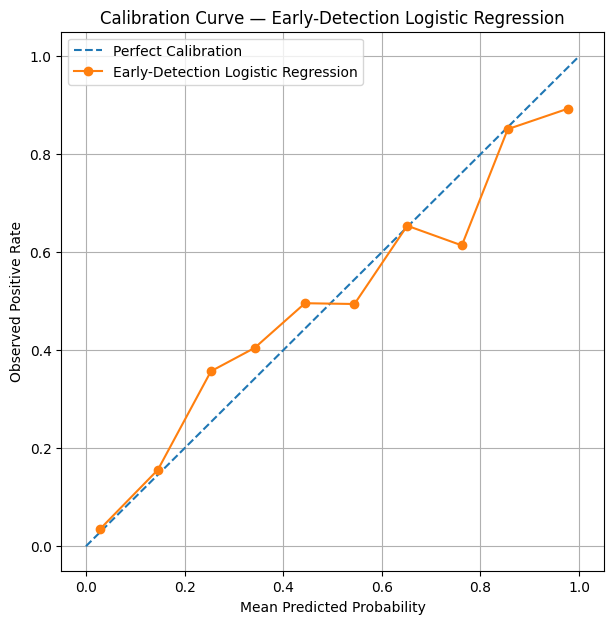


Interpretation:
The Brier score measures the accuracy of probabilistic predictions. Lower values indicate better probabilistic calibration.
The calibration curve compares predicted diabetes probabilities with the observed frequency of diabetes across probability bins.
Calibration will be interpreted together with discrimination, sensitivity, specificity, threshold behaviour, subgroup performance, and robustness.

✓ Logistic Regression calibration assessment completed.


In [61]:
# ================================================================================
# CELL 53 — LOGISTIC REGRESSION CALIBRATION ASSESSMENT
# ================================================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("LOGISTIC REGRESSION CALIBRATION ASSESSMENT")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Use the EARLY-DETECTION Logistic Regression model
# -------------------------------------------------------------------------------

early_lr_model = early_lr

print("\n✓ Early-detection Logistic Regression model identified:")
print("  Model object: early_lr")

# -------------------------------------------------------------------------------
# 2. Generate probability predictions on the untouched test set
# -------------------------------------------------------------------------------

y_test_proba_lr_early = early_lr_model.predict_proba(
    X_test_early_processed
)[:, 1]

print("\nProbability predictions generated.")
print("Number of test predictions:", len(y_test_proba_lr_early))

# -------------------------------------------------------------------------------
# 3. Use the corresponding test target
# -------------------------------------------------------------------------------

y_calibration_test = y_test

print("Number of test targets:", len(y_calibration_test))

# -------------------------------------------------------------------------------
# 4. Verify alignment
# -------------------------------------------------------------------------------

assert len(y_calibration_test) == len(y_test_proba_lr_early), (
    "Target and probability prediction lengths do not match."
)

print("✓ Test targets and probability predictions are aligned.")

# -------------------------------------------------------------------------------
# 5. Brier score
# -------------------------------------------------------------------------------

brier_lr_early = brier_score_loss(
    y_calibration_test,
    y_test_proba_lr_early
)

print("\nBrier Score:", round(brier_lr_early, 4))

# -------------------------------------------------------------------------------
# 6. Calibration curve
# -------------------------------------------------------------------------------

prob_true_lr, prob_pred_lr = calibration_curve(
    y_calibration_test,
    y_test_proba_lr_early,
    n_bins=10,
    strategy="uniform"
)

print("\nCalibration curve calculated.")
print("Number of calibration bins:", len(prob_true_lr))

# -------------------------------------------------------------------------------
# 7. Calibration table
# -------------------------------------------------------------------------------

calibration_table_lr = pd.DataFrame({
    "Mean Predicted Probability": prob_pred_lr,
    "Observed Positive Rate": prob_true_lr
})

print("\nCalibration table:")
display(
    calibration_table_lr.round(4)
)

# -------------------------------------------------------------------------------
# 8. Plot calibration curve
# -------------------------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    prob_pred_lr,
    prob_true_lr,
    marker="o",
    label="Early-Detection Logistic Regression"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title(
    "Calibration Curve — Early-Detection Logistic Regression"
)

plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------------------------------------
# 9. Interpretation
# -------------------------------------------------------------------------------

print("\nInterpretation:")

print(
    "The Brier score measures the accuracy of probabilistic predictions. "
    "Lower values indicate better probabilistic calibration."
)

print(
    "The calibration curve compares predicted diabetes probabilities "
    "with the observed frequency of diabetes across probability bins."
)

print(
    "Calibration will be interpreted together with discrimination, "
    "sensitivity, specificity, threshold behaviour, subgroup performance, "
    "and robustness."
)

print("\n✓ Logistic Regression calibration assessment completed.")

In [67]:
# ================================================================================
# CELL 54 — PRELIMINARY LOGISTIC REGRESSION THRESHOLD ANALYSIS
# ================================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

print("=" * 80)
print("PRELIMINARY LOGISTIC REGRESSION THRESHOLD ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------------
# Generate training probabilities
# -------------------------------------------------------------------------------

y_train_proba_lr_early = early_lr.predict_proba(
    X_train_early_processed
)[:, 1]

print("\nTraining probability predictions generated.")
print(
    "Number of training predictions:",
    len(y_train_proba_lr_early)
)

print(
    "Number of training targets:",
    len(y_train)
)

# -------------------------------------------------------------------------------
# Verify alignment
# -------------------------------------------------------------------------------

if len(y_train_proba_lr_early) != len(y_train):

    raise ValueError(
        "Mismatch between training probabilities and training targets."
    )

print("✓ Training targets and probability predictions are aligned.")

# -------------------------------------------------------------------------------
# Candidate thresholds
# -------------------------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_train_pred_threshold = (
        y_train_proba_lr_early >= threshold
    ).astype(int)

    sensitivity = recall_score(
        y_train,
        y_train_pred_threshold,
        zero_division=0
    )

    specificity = recall_score(
        y_train,
        y_train_pred_threshold,
        pos_label=0,
        zero_division=0
    )

    precision = precision_score(
        y_train,
        y_train_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_train_pred_threshold,
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_train,
        y_train_pred_threshold
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
        "Balanced_Accuracy": balanced_acc
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("\nPreliminary threshold performance:")

display(
    threshold_df.round(4)
)

# -------------------------------------------------------------------------------
# Preliminary F1-optimal threshold
# -------------------------------------------------------------------------------

best_train_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\nPreliminary best threshold according to training F1:")

print(
    "Threshold :",
    best_train_f1_row["Threshold"]
)

print(
    "Sensitivity:",
    round(best_train_f1_row["Sensitivity"], 4)
)

print(
    "Specificity:",
    round(best_train_f1_row["Specificity"], 4)
)

print(
    "Precision  :",
    round(best_train_f1_row["Precision"], 4)
)

print(
    "F1-score   :",
    round(best_train_f1_row["F1"], 4)
)

print("\nIMPORTANT:")
print(
    "This preliminary threshold analysis is exploratory only."
)

print(
    "The final threshold will be selected using "
    "OUT-OF-FOLD training predictions."
)

print(
    "The held-out test set will remain untouched."
)

print("\n✓ Preliminary threshold behaviour assessed.")

PRELIMINARY LOGISTIC REGRESSION THRESHOLD ANALYSIS

Training probability predictions generated.
Number of training predictions: 25227
Number of training targets: 25227
✓ Training targets and probability predictions are aligned.

Preliminary threshold performance:


,Threshold,Sensitivity,Specificity,Precision,F1,Balanced_Accuracy
0,0.10,0.9551,0.6255,0.4849,0.6432,0.7903
1,0.15,0.9251,0.6996,0.5320,0.6755,0.8124
2,0.20,0.8849,0.7629,0.5793,0.7002,0.8239
3,0.25,0.8478,0.8128,0.6256,0.7200,0.8303
4,0.30,0.8063,0.8553,0.6728,0.7336,0.8308
5,0.35,0.7522,0.8834,0.7043,0.7274,0.8178
6,0.40,0.7225,0.9076,0.7427,0.7325,0.8151
7,0.45,0.6896,0.9256,0.7738,0.7292,0.8076
8,0.50,0.6484,0.9404,0.8005,0.7164,0.7944
9,0.55,0.6143,0.9519,0.8250,0.7042,0.7831



Preliminary best threshold according to training F1:
Threshold : 0.3
Sensitivity: 0.8063
Specificity: 0.8553
Precision  : 0.6728
F1-score   : 0.7336

IMPORTANT:
This preliminary threshold analysis is exploratory only.
The final threshold will be selected using OUT-OF-FOLD training predictions.
The held-out test set will remain untouched.

✓ Preliminary threshold behaviour assessed.


In [68]:
# ================================================================================
# CELL 55 — OUT-OF-FOLD THRESHOLD SELECTION PREPARATION
# ================================================================================

print("=" * 80)
print("PREPARE OUT-OF-FOLD THRESHOLD SELECTION")
print("=" * 80)

print("""
The preliminary training-set threshold analysis from Cell 54
is exploratory only.

The final threshold will NOT be selected from training predictions
because those predictions were generated on data used to fit the model.

Instead:
 - Out-of-fold predictions will be generated from the training set.
 - Threshold selection will be performed using those OOF predictions.
 - The held-out test set will remain completely untouched.
 - The selected threshold will then be evaluated once on the test set.
""")

print("\nCurrent preliminary training-based candidate:")
print("Threshold : 0.30")
print("Status    : Exploratory only")

print("\nFinal threshold-selection method:")
print("✓ 5-fold out-of-fold predictions")
print("✓ Training data only")
print("✓ Held-out test set untouched")
print("✓ Threshold selected before final test evaluation")

print("\n✓ Ready for out-of-fold threshold selection.")

PREPARE OUT-OF-FOLD THRESHOLD SELECTION

The preliminary training-set threshold analysis from Cell 54
is exploratory only.

The final threshold will NOT be selected from training predictions
because those predictions were generated on data used to fit the model.

Instead:
 - Out-of-fold predictions will be generated from the training set.
 - Threshold selection will be performed using those OOF predictions.
 - The held-out test set will remain completely untouched.
 - The selected threshold will then be evaluated once on the test set.


Current preliminary training-based candidate:
Threshold : 0.30
Status    : Exploratory only

Final threshold-selection method:
✓ 5-fold out-of-fold predictions
✓ Training data only
✓ Held-out test set untouched
✓ Threshold selected before final test evaluation

✓ Ready for out-of-fold threshold selection.


In [64]:
# ================================================================================
# CELL 56 — OUT-OF-FOLD PROBABILITY GENERATION FOR THRESHOLD SELECTION
# ================================================================================

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone

print("=" * 80)
print("OUT-OF-FOLD PROBABILITY GENERATION FOR THRESHOLD SELECTION")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Define stratified cross-validation
# -------------------------------------------------------------------------------

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("\nCross-validation configuration:")
print("Folds        :", 5)
print("Shuffle      : True")
print("Random state :", RANDOM_STATE)

# -------------------------------------------------------------------------------
# 2. Clone the early-detection Logistic Regression model
# -------------------------------------------------------------------------------

early_lr_cv = clone(early_lr)

print("\n✓ Logistic Regression model cloned.")
print("✓ Original early_lr model remains unchanged.")

# -------------------------------------------------------------------------------
# 3. Generate OUT-OF-FOLD probability predictions
# -------------------------------------------------------------------------------

y_train_oof_proba_lr = cross_val_predict(
    early_lr_cv,
    X_train_early_processed,
    y_train,
    cv=cv_threshold,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("\nOut-of-fold probability predictions generated.")
print(
    "Number of OOF predictions:",
    len(y_train_oof_proba_lr)
)

# -------------------------------------------------------------------------------
# 4. Verify complete OOF coverage
# -------------------------------------------------------------------------------

assert len(y_train_oof_proba_lr) == len(y_train)

assert np.isfinite(
    y_train_oof_proba_lr
).all()

print("✓ Every training observation has an out-of-fold probability.")
print("✓ No missing or infinite probability values.")

# -------------------------------------------------------------------------------
# 5. Evaluate OOF discrimination
# -------------------------------------------------------------------------------

oof_roc_auc = roc_auc_score(
    y_train,
    y_train_oof_proba_lr
)

oof_pr_auc = average_precision_score(
    y_train,
    y_train_oof_proba_lr
)

print("\nOut-of-fold discrimination:")
print(
    "ROC-AUC:",
    round(oof_roc_auc, 4)
)
print(
    "PR-AUC :",
    round(oof_pr_auc, 4)
)

print(
    "\n✓ Out-of-fold probabilities generated using TRAINING data only."
)
print(
    "✓ Held-out test set remains completely untouched."
)

OUT-OF-FOLD PROBABILITY GENERATION FOR THRESHOLD SELECTION

Cross-validation configuration:
Folds        : 5
Shuffle      : True
Random state : 42

✓ Logistic Regression model cloned.
✓ Original early_lr model remains unchanged.

Out-of-fold probability predictions generated.
Number of OOF predictions: 25227
✓ Every training observation has an out-of-fold probability.
✓ No missing or infinite probability values.

Out-of-fold discrimination:
ROC-AUC: 0.9152
PR-AUC : 0.821

✓ Out-of-fold probabilities generated using TRAINING data only.
✓ Held-out test set remains completely untouched.


In [71]:
# ================================================================================
# DIAGNOSTIC — IDENTIFY OOF PROBABILITY VARIABLE
# ================================================================================

print("=" * 80)
print("IDENTIFY OOF PROBABILITY VARIABLE")
print("=" * 80)

candidate_variables = [
    name for name in globals()
    if "oof" in name.lower()
    and "proba" in name.lower()
]

print("\nOOF probability-related variables found:")

for name in candidate_variables:
    obj = globals()[name]

    try:
        print(
            f" - {name}: "
            f"type={type(obj).__name__}, "
            f"length={len(obj)}"
        )
    except TypeError:
        print(
            f" - {name}: "
            f"type={type(obj).__name__}"
        )

IDENTIFY OOF PROBABILITY VARIABLE

OOF probability-related variables found:
 - y_train_oof_proba_lr: type=ndarray, length=25227


In [72]:
# ================================================================================
# CELL 57 — OUT-OF-FOLD THRESHOLD SELECTION
# ================================================================================

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score
)

print("=" * 80)
print("OUT-OF-FOLD THRESHOLD SELECTION")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Verify OOF predictions and training targets
# -------------------------------------------------------------------------------

print("\nOOF probability variable:")
print(" - y_train_oof_proba_lr")

print("\nNumber of OOF probabilities :", len(y_train_oof_proba_lr))
print("Number of training targets :", len(y_train))

if len(y_train_oof_proba_lr) != len(y_train):
    raise ValueError(
        "OOF probabilities and training targets are not aligned."
    )

print("✓ OOF probabilities and training targets are aligned.")

# -------------------------------------------------------------------------------
# 2. Define threshold candidates
# -------------------------------------------------------------------------------

thresholds = [
    0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45,
    0.50, 0.55, 0.60, 0.65,
    0.70, 0.75, 0.80, 0.85, 0.90
]

# -------------------------------------------------------------------------------
# 3. Evaluate thresholds using OOF training predictions
# -------------------------------------------------------------------------------

oof_threshold_results = []

for threshold in thresholds:

    y_oof_pred = (
        y_train_oof_proba_lr >= threshold
    ).astype(int)

    sensitivity = recall_score(
        y_train,
        y_oof_pred,
        zero_division=0
    )

    specificity = (
        ((y_train == 0) & (y_oof_pred == 0)).sum()
        /
        (y_train == 0).sum()
    )

    precision = precision_score(
        y_train,
        y_oof_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_oof_pred,
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_train,
        y_oof_pred
    )

    oof_threshold_results.append({
        "Threshold": threshold,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
        "Balanced_Accuracy": balanced_acc
    })

oof_threshold_df = pd.DataFrame(
    oof_threshold_results
)

print("\nOut-of-fold threshold performance:")
display(oof_threshold_df.round(4))

# -------------------------------------------------------------------------------
# 4. Best threshold according to OOF F1
# -------------------------------------------------------------------------------

best_f1_row = oof_threshold_df.loc[
    oof_threshold_df["F1"].idxmax()
]

best_f1_threshold = float(
    best_f1_row["Threshold"]
)

print("\nBest threshold according to OUT-OF-FOLD F1:")
print(f"Threshold   : {best_f1_threshold:.2f}")
print(f"Sensitivity : {best_f1_row['Sensitivity']:.4f}")
print(f"Specificity : {best_f1_row['Specificity']:.4f}")
print(f"Precision   : {best_f1_row['Precision']:.4f}")
print(f"F1-score    : {best_f1_row['F1']:.4f}")
print(f"Balanced Acc: {best_f1_row['Balanced_Accuracy']:.4f}")

# -------------------------------------------------------------------------------
# 5. Select threshold closest to target sensitivity
# -------------------------------------------------------------------------------

TARGET_SENSITIVITY = 0.75

oof_threshold_df["Sensitivity_Distance"] = (
    oof_threshold_df["Sensitivity"]
    - TARGET_SENSITIVITY
).abs()

target_sensitivity_row = oof_threshold_df.loc[
    oof_threshold_df["Sensitivity_Distance"].idxmin()
]

selected_threshold = float(
    target_sensitivity_row["Threshold"]
)

print("\nThreshold closest to target sensitivity:")
print(f"Target sensitivity: {TARGET_SENSITIVITY:.2f}")

print(f"Selected threshold: {selected_threshold:.2f}")

print(
    f"Sensitivity: "
    f"{target_sensitivity_row['Sensitivity']:.4f}"
)

print(
    f"Specificity: "
    f"{target_sensitivity_row['Specificity']:.4f}"
)

print(
    f"Precision: "
    f"{target_sensitivity_row['Precision']:.4f}"
)

print(
    f"F1-score: "
    f"{target_sensitivity_row['F1']:.4f}"
)

print(
    f"Balanced Acc: "
    f"{target_sensitivity_row['Balanced_Accuracy']:.4f}"
)

# -------------------------------------------------------------------------------
# 6. Store final threshold explicitly
# -------------------------------------------------------------------------------

FINAL_THRESHOLD_OOF = selected_threshold

print("\nFinal threshold-selection decision:")
print(f"Selected threshold : {FINAL_THRESHOLD_OOF:.2f}")
print(f"Target sensitivity : {TARGET_SENSITIVITY:.2f}")

print("\nMethodological safeguards:")
print("✓ Threshold selected using OUT-OF-FOLD training predictions.")
print("✓ Held-out test set was NOT used for threshold selection.")
print("✓ Final test evaluation will be performed only once.")
print("✓ Selected threshold stored as `FINAL_THRESHOLD_OOF`.")

print("\n✓ Out-of-fold threshold selection completed.")

OUT-OF-FOLD THRESHOLD SELECTION

OOF probability variable:
 - y_train_oof_proba_lr

Number of OOF probabilities : 25227
Number of training targets : 25227
✓ OOF probabilities and training targets are aligned.

Out-of-fold threshold performance:


,Threshold,Sensitivity,Specificity,Precision,F1,Balanced_Accuracy
0,0.10,0.9607,0.6030,0.4718,0.6328,0.7819
1,0.15,0.9276,0.6876,0.5229,0.6688,0.8076
2,0.20,0.8888,0.7501,0.5676,0.6928,0.8195
3,0.25,0.8493,0.8027,0.6136,0.7125,0.8260
4,0.30,0.8032,0.8499,0.6639,0.7270,0.8266
5,0.35,0.7504,0.8828,0.7026,0.7257,0.8166
6,0.40,0.7115,0.9085,0.7416,0.7262,0.8100
7,0.45,0.6801,0.9270,0.7746,0.7243,0.8036
8,0.50,0.6363,0.9430,0.8047,0.7107,0.7897
9,0.55,0.5899,0.9551,0.8289,0.6892,0.7725



Best threshold according to OUT-OF-FOLD F1:
Threshold   : 0.30
Sensitivity : 0.8032
Specificity : 0.8499
Precision   : 0.6639
F1-score    : 0.7270
Balanced Acc: 0.8266

Threshold closest to target sensitivity:
Target sensitivity: 0.75
Selected threshold: 0.35
Sensitivity: 0.7504
Specificity: 0.8828
Precision: 0.7026
F1-score: 0.7257
Balanced Acc: 0.8166

Final threshold-selection decision:
Selected threshold : 0.35
Target sensitivity : 0.75

Methodological safeguards:
✓ Threshold selected using OUT-OF-FOLD training predictions.
✓ Held-out test set was NOT used for threshold selection.
✓ Final test evaluation will be performed only once.
✓ Selected threshold stored as `FINAL_THRESHOLD_OOF`.

✓ Out-of-fold threshold selection completed.


In [74]:


# ================================================================================
# CELL 58 — FINAL OUT-OF-FOLD-SELECTED THRESHOLD EVALUATION
# ================================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("=" * 80)
print("FINAL OUT-OF-FOLD-SELECTED THRESHOLD EVALUATION")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Retrieve threshold selected ONLY from OOF training predictions
# -------------------------------------------------------------------------------

FINAL_THRESHOLD = FINAL_THRESHOLD_OOF

print("\nFinal threshold selected from OOF training predictions:")
print(f"Threshold : {FINAL_THRESHOLD:.2f}")

# -------------------------------------------------------------------------------
# 2. Generate probability predictions on untouched test set
# -------------------------------------------------------------------------------

y_test_proba_final = early_lr.predict_proba(
    X_test_early_processed
)[:, 1]

print("\nTest probability predictions generated.")
print("Number of test predictions:", len(y_test_proba_final))
print("Number of test targets    :", len(y_test))

if len(y_test_proba_final) != len(y_test):
    raise ValueError(
        "Test probabilities and test targets are not aligned."
    )

print("✓ Test targets and probability predictions are aligned.")

# -------------------------------------------------------------------------------
# 3. Apply the OOF-selected threshold
# -------------------------------------------------------------------------------

y_test_pred_final = (
    y_test_proba_final >= FINAL_THRESHOLD
).astype(int)

# -------------------------------------------------------------------------------
# 4. Calculate final performance metrics
# -------------------------------------------------------------------------------

accuracy_final = accuracy_score(
    y_test,
    y_test_pred_final
)

precision_final = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

sensitivity_final = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

f1_final = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

roc_auc_final = roc_auc_score(
    y_test,
    y_test_proba_final
)

pr_auc_final = average_precision_score(
    y_test,
    y_test_proba_final
)

# -------------------------------------------------------------------------------
# 5. Confusion matrix and specificity
# -------------------------------------------------------------------------------

cm_final = confusion_matrix(
    y_test,
    y_test_pred_final
)

tn_final, fp_final, fn_final, tp_final = cm_final.ravel()

specificity_final = (
    tn_final / (tn_final + fp_final)
    if (tn_final + fp_final) > 0
    else 0
)

print("\nPerformance at final OOF-selected threshold:")
print(f"Accuracy     : {accuracy_final:.4f}")
print(f"Precision    : {precision_final:.4f}")
print(f"Sensitivity  : {sensitivity_final:.4f}")
print(f"Specificity  : {specificity_final:.4f}")
print(f"F1-score     : {f1_final:.4f}")
print(f"ROC-AUC      : {roc_auc_final:.4f}")
print(f"PR-AUC       : {pr_auc_final:.4f}")

print("\nConfusion Matrix:")
print(cm_final)

print("\nConfusion matrix interpretation:")
print(f"True Negatives : {tn_final}")
print(f"False Positives: {fp_final}")
print(f"False Negatives: {fn_final}")
print(f"True Positives : {tp_final}")

# -------------------------------------------------------------------------------
# 6. Compare against default 0.50 threshold
# -------------------------------------------------------------------------------

y_test_pred_default = (
    y_test_proba_final >= 0.50
).astype(int)

default_cm = confusion_matrix(
    y_test,
    y_test_pred_default
)

tn_default, fp_default, fn_default, tp_default = default_cm.ravel()

default_sensitivity = recall_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

default_specificity = (
    tn_default / (tn_default + fp_default)
    if (tn_default + fp_default) > 0
    else 0
)

print("\nThreshold comparison:")

print(
    f"Default threshold (0.50) sensitivity : "
    f"{default_sensitivity:.4f}"
)

print(
    f"Final OOF threshold ({FINAL_THRESHOLD:.2f}) "
    f"sensitivity: {sensitivity_final:.4f}"
)

print(
    f"Default threshold (0.50) specificity : "
    f"{default_specificity:.4f}"
)

print(
    f"Final OOF threshold ({FINAL_THRESHOLD:.2f}) "
    f"specificity: {specificity_final:.4f}"
)

# -------------------------------------------------------------------------------
# 7. Methodological interpretation
# -------------------------------------------------------------------------------

print("\nInterpretation:")
print(
    "The final classification threshold was selected exclusively "
    "from out-of-fold training predictions."
)

print(
    "The held-out test set was not used during threshold selection."
)

print(
    "The selected threshold was then evaluated once on the "
    "untouched held-out test set."
)

print(
    "This preserves the independence of the final test evaluation "
    "while allowing the threshold to reflect the intended "
    "early-detection sensitivity objective."
)

print("\n✓ Final OOF-selected threshold evaluated on untouched test set.")

FINAL OUT-OF-FOLD-SELECTED THRESHOLD EVALUATION

Final threshold selected from OOF training predictions:
Threshold : 0.35

Test probability predictions generated.
Number of test predictions: 6242
Number of test targets    : 6242
✓ Test targets and probability predictions are aligned.

Performance at final OOF-selected threshold:
Accuracy     : 0.8395
Precision    : 0.7032
Sensitivity  : 0.6889
Specificity  : 0.8943
F1-score     : 0.6960
ROC-AUC      : 0.9009
PR-AUC       : 0.7662

Confusion Matrix:
[[4093  484]
 [ 518 1147]]

Confusion matrix interpretation:
True Negatives : 4093
False Positives: 484
False Negatives: 518
True Positives : 1147

Threshold comparison:
Default threshold (0.50) sensitivity : 0.5694
Final OOF threshold (0.35) sensitivity: 0.6889
Default threshold (0.50) specificity : 0.9347
Final OOF threshold (0.35) specificity: 0.8943

Interpretation:
The final classification threshold was selected exclusively from out-of-fold training predictions.
The held-out test set wa